# Wiki de gráficos: matplotlib × seaborn × plotly

Este notebook é uma **referência de consulta**. Cada seção apresenta um tipo de gráfico com:

1. **Quando usar** e quais cuidados ter;
2. **O mesmo gráfico nas três bibliotecas**, com os mesmos dados, o mesmo título, as mesmas cores e o mesmo tamanho;
3. **As personalizações explicadas**, parâmetro por parâmetro;
4. **Uma comparação** do que cada biblioteca facilitou ou dificultou.

Os exemplos usam a base de **compras e fraudes** (`dados_compras.csv` + `fraudes_scores.csv`).

| # | Gráfico | Pergunta respondida com os dados de fraude |
|---|---|---|
| 1 | Barras | A entrega de cada documento muda a taxa de fraude? |
| 2 | Linha | Como o volume de compras evolui dia a dia em cada país? |
| 3 | Dispersão | O score do modelo separa fraudes de compras legítimas? |
| 4 | Heatmap | Quais variáveis se correlacionam entre si e com a fraude? |
| 5 | Boxplot | Fraudes têm valores de compra diferentes? |
| 6 | Violino | Como o score do modelo se distribui em cada país? |
| 7 | Histograma | Qual a forma da distribuição do score em cada grupo? |
| 8 | Pizza | Qual a participação de cada país nas compras? |

> **Como reaproveitar:** cada célula de gráfico é independente. Copie a célula de **preparação dos dados** e a célula da biblioteca escolhida, troque as colunas e pronto.

## Referência rápida: qual gráfico e qual biblioteca

### Qual gráfico usar

| Gráfico | Pergunta que responde | Dados típicos | Cuidados / evite quando | Biblioteca recomendada |
|---|---|---|---|---|
| **Bar** (barras) | Como categorias se comparam? | 1 categórica + 1 numérica (ou contagem) | Eixo Y deve começar no zero. Com muitas categorias, use barras horizontais e ordene. | **seaborn** (`sns.barplot` já agrega média + IC; `sns.countplot` para contagens) |
| **Line** (linha) | Como algo evolui ao longo do tempo/ordem? | X ordenado (datas, etapas) + Y numérico | Não use com X categórico sem ordem: a linha sugere continuidade que não existe. | **matplotlib/pandas** (`df.plot()`) para séries simples; **plotly** (`px.line`) se a série for longa e o zoom ajudar |
| **Scatter** (dispersão) | Existe relação entre duas variáveis numéricas? | 2 numéricas (+ cor/tamanho para uma 3ª) | Muitos pontos se sobrepõem: use `alpha`, amostragem ou `hexbin`. Correlação não é causalidade. | **seaborn** (`sns.scatterplot`, `sns.regplot` com reta); **plotly** quando o hover para identificar pontos importa |
| **Heatmap** | Como uma matriz de valores se distribui? Quais variáveis se correlacionam? | Matriz: `df.corr()`, tabela cruzada, dia × hora | Para correlação, use paleta divergente centrada em 0 (`cmap="coolwarm", center=0`). Matrizes grandes ficam ilegíveis com `annot=True`. | **seaborn** (`sns.heatmap`) |
| **Boxplot** | Como a distribuição varia entre grupos? Há outliers? | 1 categórica + 1 numérica | Esconde a forma da distribuição (bimodalidade some). Público leigo costuma não saber ler quartis. | **seaborn** (`sns.boxplot`) |
| **Violin** | Mesma pergunta do boxplot, mas mostrando a forma da distribuição | 1 categórica + 1 numérica, amostras médias/grandes | Com poucos dados a curva suavizada engana: sobreponha os pontos (`sns.stripplot`) ou use `inner="quartile"`. | **seaborn** (`sns.violinplot`, `split=True` para comparar 2 subgrupos) |
| **Histograma** | Como uma variável numérica se distribui? | 1 numérica | O número de bins muda a leitura; teste alguns valores. | **seaborn** (`sns.histplot(kde=True)`) |
| **Pizza** (bônus) | Qual a proporção de cada parte no todo? | Poucas categorias que somam 100% | Evite com mais de 3–4 fatias; barras quase sempre comunicam melhor. | **matplotlib** (`plt.pie`) ou **plotly** (`px.pie`) |

### Qual biblioteca escolher

| Biblioteca | Use quando | Pontos fortes | Limitações |
|---|---|---|---|
| **pandas `.plot()`** | Exploração rápida, "só quero ver" | Uma linha de código direto do DataFrame | Pouco controle; visual básico |
| **matplotlib** | Controle total, figura para artigo/relatório estático, gráficos fora do padrão | Base de tudo; customiza cada detalhe; exporta PNG/PDF/SVG | Verboso; visual padrão datado |
| **seaborn** | Análise exploratória e estatística com DataFrames | Agrega e calcula IC sozinho; `hue`, `col`, `row` facilitam comparar grupos; visual bonito por padrão | Funciona melhor com dados em formato "long"; para ajustes finos você volta ao matplotlib |
| **plotly (express)** | Interatividade: hover, zoom, filtros; dashboards (Dash/Streamlit); apresentar em notebook ou web | Sintaxe parecida com seaborn (`px.scatter(df, x=, y=, color=)`); interativo sem esforço | Arquivos pesados; menos adequado para PDF/impressão |

### Regra de bolso

| Objetivo | Gráfico |
|---|---|
| Comparar categorias | Bar |
| Mudança no tempo | Line |
| Relação entre duas numéricas | Scatter |
| Distribuição de uma variável | Histograma |
| Distribuição entre grupos | Boxplot (resumo) ou Violin (forma) |
| Matriz / correlação | Heatmap |

> **Para a biblioteca:** seaborn para explorar, matplotlib para ajustar e publicar, plotly para interagir.

## 0. Preparação do ambiente

### Instalação

No terminal, dentro da pasta do projeto:

```bash
uv add pandas numpy matplotlib seaborn plotly nbformat
```

> O `nbformat` é necessário para o plotly desenhar os gráficos dentro do notebook.

In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

### Um tema visual comum às três bibliotecas

Para a comparação ser justa, as três bibliotecas usam **o mesmo tamanho, as mesmas fontes, a mesma grade e as mesmas cores**. Assim, a diferença que você vê é de **código e recursos**, não de estilo padrão.

- **matplotlib e seaborn** compartilham o mesmo motor: o seaborn desenha *em cima* do matplotlib. Por isso basta configurar o `plt.rcParams` uma vez e os dois seguem o mesmo visual.
- **plotly** tem um motor próprio (roda no navegador). O equivalente ao `rcParams` é um **template**, que registramos e deixamos como padrão.

| matplotlib (`rcParams`) | plotly (template) | Efeito |
|---|---|---|
| `figure.figsize` + `figure.dpi` | `width`, `height` | Tamanho: 9 × 5 polegadas a 100 dpi = 900 × 500 pixels |
| `axes.spines.top/right = False` | `showline` apenas nos eixos x/y | Remove as bordas de cima e da direita |
| `axes.grid.axis = "y"` | `xaxis.showgrid = False` | Grade só na horizontal, mais limpa |
| `axes.titlelocation = "left"` | `title.x = 0` | Título alinhado à esquerda, como em relatórios |
| `formatar_numero()` (função nossa) | `separators=",."` | Números no padrão brasileiro: `1.234,5` |

In [ ]:
# ---------- Tamanho padrão (igual nas três bibliotecas) ----------
LARGURA, ALTURA = 900, 500          # pixels
DPI = 100                           # 900 px / 100 dpi = 9 polegadas

# ---------- Cores de texto e de "moldura" ----------
TINTA_PRINCIPAL = "#0b0b0b"         # títulos
TINTA_SECUNDARIA = "#52514e"        # rótulos e números
COR_EIXO = "#c3c2b7"                # linhas dos eixos
COR_GRADE = "#e1e0d9"               # linhas de grade

# ---------- matplotlib (e, portanto, seaborn) ----------
plt.rcParams.update({
    "figure.figsize": (LARGURA / DPI, ALTURA / DPI),
    "figure.dpi": DPI,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlecolor": TINTA_PRINCIPAL,
    "axes.titlepad": 30,            # espaço entre o título e o gráfico: a legenda fica ali
    "axes.labelcolor": TINTA_SECUNDARIA,
    "axes.edgecolor": COR_EIXO,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,         # grade atrás das barras/pontos
    "grid.color": COR_GRADE,
    "grid.linewidth": 0.8,
    "xtick.color": TINTA_SECUNDARIA,
    "ytick.color": TINTA_SECUNDARIA,
    "legend.frameon": False,
})

# ---------- plotly ----------
pio.templates["wiki"] = go.layout.Template(layout=dict(
    width=LARGURA,
    height=ALTURA,
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=13, color=TINTA_SECUNDARIA),
    title=dict(font=dict(size=18, color=TINTA_PRINCIPAL, weight="bold"), x=0, xref="paper", xanchor="left",
               y=0.97, yref="container", yanchor="top"),
    separators=",.",                # vírgula decimal, ponto de milhar
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=70, r=40, t=100, b=60),
    xaxis=dict(showgrid=False, showline=True, linecolor=COR_EIXO, ticks="outside", tickcolor=COR_EIXO),
    yaxis=dict(showgrid=True, gridcolor=COR_GRADE, showline=True, linecolor=COR_EIXO, zeroline=False),
    legend=dict(bgcolor="rgba(0,0,0,0)", title_text=""),
))
pio.templates.default = "plotly_white+wiki"   # combina o tema branco do plotly com o nosso


def formatar_numero(valor, casas=0):
    # 1234.5 -> "1.234,5" (padrão brasileiro)
    texto = f"{valor:,.{casas}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")


formatar_numero(1234567.891, 2)

'1.234.567,89'

### Paleta de cores semântica

A regra de ouro: **a cor segue o significado, não a posição**. "Fraude" é laranja em *todos* os gráficos; "BR" é verde-água em *todos* os gráficos. Quem leu um gráfico já sabe ler o próximo.

Guardamos as cores em **dicionários** (`categoria → cor`). As três bibliotecas aceitam esse formato:

| Biblioteca | Parâmetro que recebe o dicionário |
|---|---|
| matplotlib | não recebe direto: fazemos um `for categoria, cor in CORES.items()` |
| seaborn | `palette=CORES` |
| plotly | `color_discrete_map=CORES` |

As cores foram testadas para **daltonismo** (protanopia, deuteranopia, tritanopia). Para o heatmap, usamos uma escala **divergente**: azul (negativo), cinza (zero) e vermelho (positivo).

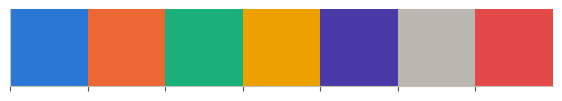

In [12]:
# Cada dicionário define a cor E a ordem das categorias (a ordem das chaves)
CORES_STATUS = {"Legítima": "#2a78d6", "Fraude": "#eb6834"}
CORES_PAIS = {"BR": "#1baf7a", "AR": "#eda100", "Outros": "#4a3aa7"}
CORES_ENTREGA = {"Entregou": "#b9b8b0", "Não entregou": "#e34948"}   # destaque no que importa

ORDEM_STATUS = list(CORES_STATUS)
ORDEM_PAIS = list(CORES_PAIS)
ORDEM_ENTREGA = list(CORES_ENTREGA)

# Escala divergente (heatmap): mesmas 3 cores para matplotlib/seaborn e plotly
CORES_DIVERGENTES = ["#2a78d6", "#f0efec", "#e34948"]
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list("azul_cinza_vermelho", CORES_DIVERGENTES)
ESCALA_DIVERGENTE_PLOTLY = [[0.0, CORES_DIVERGENTES[0]], [0.5, CORES_DIVERGENTES[1]], [1.0, CORES_DIVERGENTES[2]]]

sns.palplot(list(CORES_STATUS.values()) + list(CORES_PAIS.values()) + list(CORES_ENTREGA.values()))

### Carregando e preparando os dados

As duas bases têm a mesma chave, `id_compra`. Juntamos tudo num único DataFrame `df` com `merge` e criamos colunas auxiliares:

| Coluna nova | Para que serve |
|---|---|
| `data_compra` como `datetime` | permite agrupar por dia e formatar o eixo de datas |
| `dia` | a data sem o horário (para contar compras por dia) |
| `status` | `"Legítima"` / `"Fraude"`, mais legível que `0` / `1` nas legendas |
| `produto_curto` | nome do produto cortado em 50 caracteres (para o hover do plotly) |

> Ajuste `PASTA_DADOS` para o caminho onde estão os seus CSVs.

In [ ]:
PASTA_DADOS = "../1.data/2.processed"

compras = pd.read_csv(PASTA_DADOS + "/dados_compras.csv")
scores = pd.read_csv(PASTA_DADOS + "/fraudes_scores.csv")

# A coluna "fraude" existe nas duas bases: mantemos só a de compras
df = compras.merge(scores.drop(columns="fraude"), on="id_compra", how="inner")

df["data_compra"] = pd.to_datetime(df["data_compra"])
df["dia"] = df["data_compra"].dt.normalize()
df["status"] = df["fraude"].map({0: "Legítima", 1: "Fraude"})
df["produto_curto"] = df["produto"].str.slice(0, 50) #pegando somente os primeiros 50 caracteres

print(f"{formatar_numero(len(df))} compras | taxa de fraude: {formatar_numero(df['fraude'].mean() * 100, 1)}%")
df.head(3)

150.000 compras | taxa de fraude: 5,0%


,id_compra,produto,categoria_produto,valor_compra,data_compra,dia_semana,hora_compra,pais,pais_agrupado,entrega_doc_1,...,score_5,score_6,score_7,score_8,score_9,score_10,score_fraude_modelo,dia,status,produto_curto
0,1,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,5.64,2020-03-27 11:51:16,Sexta,11:51,BR,BR,1,...,0.444828,1.0,5,0.883598,240.0,102.0,66,2020-03-27,Legítima,Máquininha Corta Barba Cabelo Peito Perna Pelo...
1,3,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,339.32,2020-03-25 18:13:38,Quarta,18:13,AR,AR,1,...,0.000000,19.0,23,0.516368,1779.0,77.0,95,2020-03-25,Legítima,Bicicleta Mountain Fire Bird Rodado 29 Alumini...
2,7,"Corpinho Avulso Joseph, Josepha Ou Placa Sem Sexo",cat_5d6059e,10.56,2020-03-22 19:20:24,Domingo,19:20,BR,BR,0,...,0.398000,0.0,11,0.204991,127.0,125.0,71,2020-03-22,Legítima,"Corpinho Avulso Joseph, Josepha Ou Placa Sem Sexo"


### Uma amostra para os gráficos de distribuição

Com **150 mil linhas** e **só 5% de fraudes**, dois problemas aparecem:

1. **Desbalanceamento:** num gráfico de pontos, as 7.500 fraudes somem embaixo de 142.500 legítimas.
2. **Peso no plotly:** o plotly envia **todos os pontos** para o navegador. Um boxplot com 150 mil valores deixa o notebook lento e pesado (matplotlib e seaborn só guardam a imagem).

Solução: uma **amostra balanceada**, com 5.000 compras de cada grupo, usada **igualmente nas três bibliotecas** nos gráficos de dispersão, boxplot, violino e histograma. Gráficos que mostram contagens ou taxas (barras, linha, heatmap e pizza) usam a base completa.

> **Atenção:** na amostra, 50% são fraudes. Ela serve para comparar a **forma** das distribuições, nunca para calcular a taxa de fraude.

Ordenamos a amostra com as legítimas primeiro para que, nos gráficos de pontos, as **fraudes sejam desenhadas por cima**.

In [14]:
amostra = (
    df.groupby("status")
      .sample(n=5_000, random_state=42)          # random_state: mesma amostra sempre
      .sort_values("status", key=lambda s: s.map({"Legítima": 0, "Fraude": 1}))
      .reset_index(drop=True)
)

amostra["status"].value_counts()

status
Legítima    5000
Fraude      5000
Name: count, dtype: int64

---
## 1. Gráfico de barras

**Quando usar:** comparar uma medida entre **categorias** (países, produtos, grupos). Com `hue` (cor por subgrupo), compara categorias **dentro** de categorias.

**Cuidados:**
- O eixo de valores **sempre começa no zero**: a altura da barra é a informação.
- Muitas categorias → barras **horizontais**, ordenadas do maior para o menor.
- Rótulos de valor ajudam quando há poucas barras. Com muitas, poluem.
- Destaque o grupo importante com cor forte e deixe o resto em cinza.

**Exemplo:** a taxa de fraude muda quando o cliente entrega (ou não) cada documento?

### Preparando os dados

As colunas `entrega_doc_1`, `entrega_doc_2` e `entrega_doc_3` estão **lado a lado** (formato *largo*). Para colorir por "entregou / não entregou" precisamos empilhá-las (formato *longo*) com `melt`:

| documento | entregou | fraude |
|---|---|---|
| Documento 1 | Entregou | 0 |
| Documento 2 | Não entregou | 0 |
| ... | ... | ... |

Como `fraude` vale 0 ou 1, **a média de `fraude` é a taxa de fraude**.

In [15]:
colunas_docs = ["entrega_doc_1", "entrega_doc_2", "entrega_doc_3"]

taxa_docs = (
    df.melt(id_vars="fraude", value_vars=colunas_docs, var_name="documento", value_name="entregou")
      .assign(
          documento=lambda d: d["documento"].str.replace("entrega_doc_", "Documento "),
          entregou=lambda d: d["entregou"].map({1: "Entregou", 0: "Não entregou"}),
      )
      .groupby(["documento", "entregou"], as_index=False)["fraude"].mean()
      .rename(columns={"fraude": "taxa_fraude"})
)
taxa_docs["taxa_fraude"] = taxa_docs["taxa_fraude"] * 100   # em %

TAXA_MEDIA = df["fraude"].mean() * 100
TITULO_BARRAS = "Sem o documento 1, a taxa de fraude salta para 16%"
DOCUMENTOS = sorted(taxa_docs["documento"].unique())

taxa_docs

,documento,entregou,taxa_fraude
0,Documento 1,Entregou,3.797478
1,Documento 1,Não entregou,16.112515
2,Documento 2,Entregou,6.450542
3,Documento 2,Não entregou,4.722458
4,Documento 3,Entregou,2.912341
5,Documento 3,Não entregou,7.595221


### matplotlib

No matplotlib **não existe "barra agrupada" pronta**: nós calculamos onde cada barra fica.

- `x = np.arange(3)` → posições 0, 1, 2 (uma por documento);
- cada grupo é desenhado **deslocado** meia largura para a esquerda ou para a direita.

| Personalização | Código | Efeito |
|---|---|---|
| Barras agrupadas | `ax.bar(x + deslocamento, ...)` | Uma chamada por grupo, deslocada no eixo x |
| Respiro entre barras | `width=LARGURA_BARRA * 0.92` | Barra um pouco mais fina que o espaço: cria um vão branco entre elas |
| Rótulo de valor | `ax.bar_label(barras, labels=...)` | Escreve o valor em cima de cada barra |
| Eixo em % | `mticker.PercentFormatter()` | Transforma `16` em `16%` |
| Ticks redondos | `mticker.MultipleLocator(4)` | Um tick a cada 4 pontos. Sem isso, o matplotlib escolhe 2,5 em 2,5 e o formatador arredonda para "2%", "5%", "8%"... enganoso |
| Linha de referência | `ax.axhline(TAXA_MEDIA)` + `ax.annotate` | Mostra a média geral. O texto vai em `x=0.5`, no vão entre os grupos 1 e 2, para não cobrir barras |
| Folga no topo | `ax.margins(y=0.15)` | Espaço para os rótulos não baterem no título |

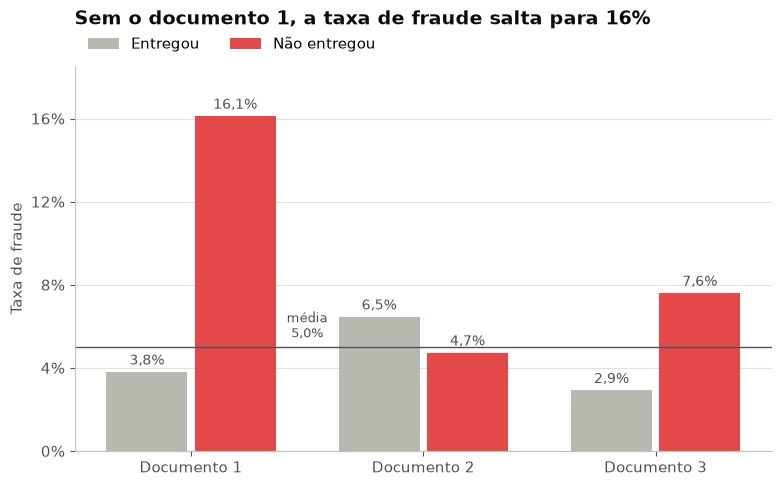

In [16]:
fig, ax = plt.subplots()

x = np.arange(len(DOCUMENTOS))
LARGURA_BARRA = 0.38

for i, (grupo, cor) in enumerate(CORES_ENTREGA.items()):
    valores = taxa_docs[taxa_docs["entregou"] == grupo].set_index("documento").loc[DOCUMENTOS, "taxa_fraude"]
    deslocamento = (i - 0.5) * LARGURA_BARRA          # -0.19 para o 1º grupo, +0.19 para o 2º
    barras = ax.bar(x + deslocamento, valores, width=LARGURA_BARRA * 0.92, color=cor, label=grupo)
    ax.bar_label(barras, labels=[f"{formatar_numero(v, 1)}%" for v in valores],
                 padding=3, fontsize=10, color=TINTA_SECUNDARIA)

# Linha da média geral
ax.axhline(TAXA_MEDIA, color=TINTA_SECUNDARIA, linewidth=1)
ax.annotate(f"média\n{formatar_numero(TAXA_MEDIA, 1)}%", xy=(0.5, TAXA_MEDIA),   # x=0,5: no vão entre os grupos
            xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9, color=TINTA_SECUNDARIA)

ax.set_xticks(x, DOCUMENTOS)
ax.yaxis.set_major_locator(mticker.MultipleLocator(4))     # ticks de 4 em 4 pontos percentuais
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.margins(y=0.15)
ax.set(title=TITULO_BARRAS, xlabel="", ylabel="Taxa de fraude")
ax.legend(loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

### seaborn

O seaborn entende o formato longo: basta dizer qual coluna vai no `x`, no `y` e na cor (`hue`). **O agrupamento e o deslocamento das barras são automáticos.**

| Personalização | Código | Efeito |
|---|---|---|
| Cor por grupo | `hue="entregou", palette=CORES_ENTREGA` | Usa o dicionário de cores |
| Ordem dos grupos | `hue_order=ORDEM_ENTREGA` | Garante a mesma ordem da legenda nas três bibliotecas |
| Respiro entre barras | `gap=0.08` | Vão entre as barras de um mesmo grupo (seaborn ≥ 0.13) |
| Rótulos | `for barras in ax.containers: ax.bar_label(...)` | Cada `container` é um grupo de barras |
| Sem barra de erro | `errorbar=None` | Os dados já estão agregados (1 linha por barra) |
| Cores fiéis | `saturation=1` | **Armadilha:** em barras, boxplots e violinos, o seaborn "desbota" as cores para 75% por padrão. Sem isso, o laranja do seaborn não bate com o das outras bibliotecas |

O restante (eixo em %, linha da média, legenda) é **matplotlib puro**, porque o seaborn devolve um `ax` do matplotlib.

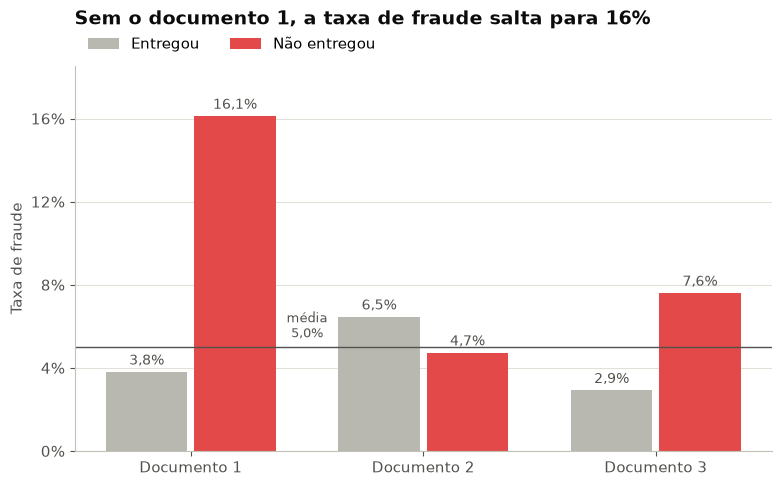

In [17]:
fig, ax = plt.subplots()

sns.barplot(
    data=taxa_docs, x="documento", y="taxa_fraude",
    hue="entregou", hue_order=ORDEM_ENTREGA, palette=CORES_ENTREGA,
    order=DOCUMENTOS, width=0.76, gap=0.08, errorbar=None, saturation=1, ax=ax,
)

for barras in ax.containers:
    ax.bar_label(barras, labels=[f"{formatar_numero(v, 1)}%" for v in barras.datavalues],
                 padding=3, fontsize=10, color=TINTA_SECUNDARIA)

ax.axhline(TAXA_MEDIA, color=TINTA_SECUNDARIA, linewidth=1)
ax.annotate(f"média\n{formatar_numero(TAXA_MEDIA, 1)}%", xy=(0.5, TAXA_MEDIA),   # x=0,5: no vão entre os grupos
            xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9, color=TINTA_SECUNDARIA)

ax.yaxis.set_major_locator(mticker.MultipleLocator(4))     # ticks de 4 em 4 pontos percentuais
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.margins(y=0.15)
ax.set(title=TITULO_BARRAS, xlabel="", ylabel="Taxa de fraude")
ax.legend(title=None, loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

#### Recurso exclusivo do seaborn: agregação automática

O seaborn também **calcula a média sozinho** a partir dos dados brutos e desenha a **barra de erro** (aqui, o erro padrão). Útil na análise exploratória: você vê se a diferença entre grupos é maior que a incerteza.

```python
dados_longos = df.melt(id_vars="fraude", value_vars=colunas_docs, var_name="documento", value_name="entregou")
sns.barplot(data=dados_longos, x="documento", y="fraude", hue="entregou", errorbar="se")
```

> O padrão é `errorbar=("ci", 95)`, que usa *bootstrap* e pode demorar com centenas de milhares de linhas. `"se"` é instantâneo.

### plotly

O `plotly.express` (`px`) tem a sintaxe mais parecida com a do seaborn: `x`, `y` e `color` apontam para colunas.

| Personalização | Código | Efeito |
|---|---|---|
| Barras agrupadas | `barmode="group"` | Lado a lado (o padrão do plotly é empilhar: `"relative"`) |
| Cores e ordem | `color_discrete_map=CORES_ENTREGA`, `category_orders={...}` | Mesmo papel de `palette` e `hue_order` |
| Rótulos | `texttemplate="%{y:.1f}%"`, `textposition="outside"` | Valor com 1 casa decimal acima da barra |
| Hover | `hovertemplate="...<extra></extra>"` | Texto ao passar o mouse; `<extra></extra>` esconde a caixinha com o nome do grupo |
| Linha de referência | `fig.add_hline(...)` + `fig.add_annotation(...)` | Linha horizontal + texto posicionado no vão entre os grupos |
| Ticks redondos | `dtick=4` | Um tick a cada 4 pontos percentuais |
| Respiro | `bargap`, `bargroupgap` | Espaço entre grupos e entre barras do grupo |
| Nomes dos eixos | `labels={"coluna": "Nome bonito"}` | Renomeia eixos, legenda e hover de uma vez |

Interatividade grátis: clique num item da legenda para esconder o grupo; dê duplo clique para isolá-lo.

In [18]:
fig = px.bar(
    taxa_docs, x="documento", y="taxa_fraude", color="entregou",
    barmode="group",
    color_discrete_map=CORES_ENTREGA,
    category_orders={"entregou": ORDEM_ENTREGA, "documento": DOCUMENTOS},
    labels={"documento": "", "taxa_fraude": "Taxa de fraude", "entregou": ""},
    title=TITULO_BARRAS,
)

fig.update_traces(
    texttemplate="%{y:.1f}%", textposition="outside", textfont_color=TINTA_SECUNDARIA,
    hovertemplate="%{x} · %{fullData.name}<br>Taxa de fraude: %{y:.2f}%<extra></extra>",
)
fig.add_hline(y=TAXA_MEDIA, line_width=1, line_color=TINTA_SECUNDARIA)
fig.add_annotation(   # x=0.5: no vão entre os grupos (eixo de categorias também aceita posição numérica)
    x=0.5, y=TAXA_MEDIA, text=f"média<br>{formatar_numero(TAXA_MEDIA, 1)}%",
    showarrow=False, yanchor="bottom", yshift=2, font=dict(size=11, color=TINTA_SECUNDARIA),
)
fig.update_yaxes(ticksuffix="%", dtick=4, range=[0, taxa_docs["taxa_fraude"].max() * 1.15])
fig.update_layout(bargap=0.24, bargroupgap=0.08,
                  legend=dict(orientation="h", x=0, xanchor="left", y=1, yanchor="bottom"))

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Barras agrupadas | Manual: calcular deslocamentos | Automático com `hue` | Automático com `barmode="group"` |
| Rótulos de valor | `bar_label` | `bar_label` em cada `container` | `texttemplate` |
| Dados brutos | Precisa agregar antes | **Agrega sozinho**, com barra de erro | Precisa agregar antes (`px.histogram` agrega contagens/somas, mas sem barra de erro) |
| Interatividade | Não | Não | Hover, zoom, esconder grupos |

**Escolha para barras:** seaborn na exploração (agrega e mostra a incerteza); plotly para apresentar ou para painéis; matplotlib quando precisar de um arranjo fora do padrão.

**Leitura do exemplo:** quem **não entrega o documento 1** frauda mais de 4 vezes mais do que quem entrega (16,1% contra 3,8%). O documento 3 segue a mesma direção, mais fraco. No documento 2 o efeito se inverte: quem entrega frauda um pouco mais.

---
## 2. Gráfico de linha

**Quando usar:** mostrar a **evolução** de uma medida ao longo de algo **ordenado**: datas, horas, etapas.

**Cuidados:**
- Só use linha se o eixo x tiver **ordem natural**. Ligar categorias sem ordem (países, produtos) sugere uma continuidade que não existe.
- Com várias séries, **rotule direto no fim da linha**: o leitor não precisa ir e voltar da legenda.
- Até ~5 séries. Mais que isso vira "espaguete": use gráficos pequenos lado a lado.
- **Nunca use dois eixos y** (um à esquerda, outro à direita) para medidas diferentes: a escala é arbitrária e o gráfico inventa relações. Faça dois gráficos.

**Exemplo:** número de compras por dia em cada grupo de país.

In [19]:
compras_dia = (
    df.groupby(["dia", "pais_agrupado"])
      .size()
      .reset_index(name="compras")
)

TITULO_LINHA = "Compras por dia: o volume cai nos fins de semana"
ULTIMO_DIA = compras_dia["dia"].max()

compras_dia.head()

,dia,pais_agrupado,compras
0,2020-03-08,AR,555
1,2020-03-08,BR,2192
2,2020-03-08,Outros,91
3,2020-03-09,AR,1009
4,2020-03-09,BR,3000


### matplotlib

| Personalização | Código | Efeito |
|---|---|---|
| Uma linha por país | `for pais, cor in CORES_PAIS.items(): ax.plot(...)` | Cor fixa por país |
| Rótulo no fim da linha | `ax.annotate(pais, xy=(último dia, último valor), xytext=(6, 0), textcoords="offset points")` | Nome do país ao lado da linha, 6 pontos à direita |
| Ticks semanais | `mdates.WeekdayLocator(byweekday=mdates.MO)` | Um tick por segunda-feira |
| Formato de data | `mdates.DateFormatter("%d/%m")` | `09/03` em vez de `2020-03-09` |
| Milhar com ponto | `mticker.FuncFormatter(lambda v, _: formatar_numero(v))` | `2.000` em vez de `2000` |
| Espaço para os rótulos | `ax.set_xlim(right=ULTIMO_DIA + pd.Timedelta(days=3))` | Estende o eixo 3 dias à direita |

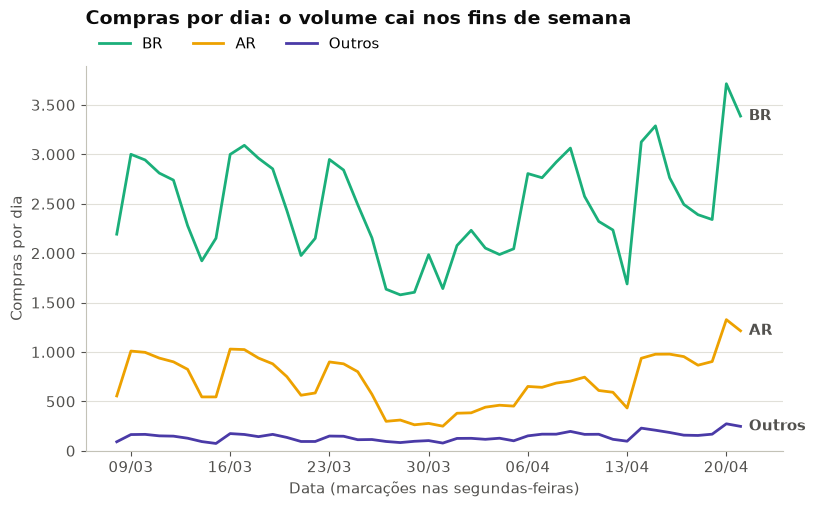

In [20]:
fig, ax = plt.subplots()

for pais, cor in CORES_PAIS.items():
    serie = compras_dia[compras_dia["pais_agrupado"] == pais]
    ax.plot(serie["dia"], serie["compras"], color=cor, linewidth=2, label=pais)
    ultimo = serie.iloc[-1]
    ax.annotate(pais, xy=(ultimo["dia"], ultimo["compras"]), xytext=(6, 0), textcoords="offset points",
                va="center", fontweight="bold", color=TINTA_SECUNDARIA)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: formatar_numero(v)))
ax.set_xlim(right=ULTIMO_DIA + pd.Timedelta(days=3))
ax.set_ylim(bottom=0)
ax.set(title=TITULO_LINHA, xlabel="Data (marcações nas segundas-feiras)", ylabel="Compras por dia")
ax.legend(loc="lower left", ncols=3, bbox_to_anchor=(0, 1))

plt.show()

### seaborn

`sns.lineplot` desenha todas as séries numa chamada só (`hue`). O resto é igual ao matplotlib.

| Personalização | Código | Efeito |
|---|---|---|
| Uma linha por país | `hue="pais_agrupado", palette=CORES_PAIS, hue_order=ORDEM_PAIS` | Séries e cores automáticas |
| Espessura | `linewidth=2` | Mesmo traço das outras bibliotecas |

> **Armadilha:** se houver **mais de um valor de y para o mesmo x** (por exemplo, passar `df` direto sem agrupar por dia), o `lineplot` calcula a **média** e desenha uma **faixa de confiança** ao redor. Às vezes é o que você quer; quase sempre é surpresa. Agregue antes ou use `errorbar=None`.

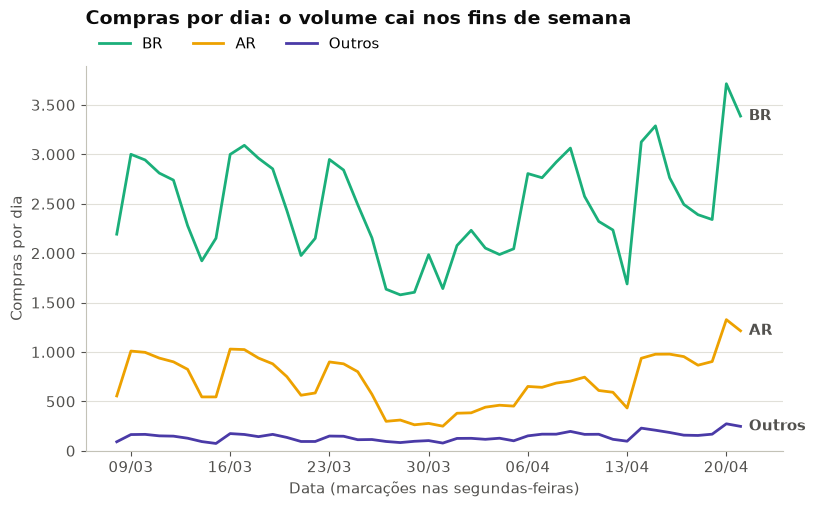

In [21]:
fig, ax = plt.subplots()

sns.lineplot(
    data=compras_dia, x="dia", y="compras",
    hue="pais_agrupado", hue_order=ORDEM_PAIS, palette=CORES_PAIS,
    linewidth=2, ax=ax,
)

for pais in ORDEM_PAIS:
    ultimo = compras_dia[compras_dia["pais_agrupado"] == pais].iloc[-1]
    ax.annotate(pais, xy=(ultimo["dia"], ultimo["compras"]), xytext=(6, 0), textcoords="offset points",
                va="center", fontweight="bold", color=TINTA_SECUNDARIA)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: formatar_numero(v)))
ax.set_xlim(right=ULTIMO_DIA + pd.Timedelta(days=3))
ax.set_ylim(bottom=0)
ax.set(title=TITULO_LINHA, xlabel="Data (marcações nas segundas-feiras)", ylabel="Compras por dia")
ax.legend(title=None, loc="lower left", ncols=3, bbox_to_anchor=(0, 1))

plt.show()

### plotly

Aqui o plotly brilha: **hover unificado** (passe o mouse e veja os três países no mesmo dia) e **zoom** arrastando o mouse.

| Personalização | Código | Efeito |
|---|---|---|
| Hover unificado | `hovermode="x unified"` | Uma caixa com todas as séries para o dia sob o mouse |
| Formato do hover | `hovertemplate="%{y:,.0f} compras"` | Número com separador de milhar |
| Ticks semanais | `dtick=7 * 24 * 60 * 60 * 1000`, `tick0="2020-03-09"` | Um tick a cada 7 dias (em milissegundos), começando numa segunda |
| Formato de data | `tickformat="%d/%m"` | `09/03` |
| Rótulo no fim | `fig.add_annotation(x=..., y=..., xanchor="left", xshift=6)` | Equivalente ao `annotate` do matplotlib |
| Barra de navegação | `fig.update_xaxes(rangeslider_visible=True)` | (opcional) mini-gráfico para escolher o período |

In [22]:
fig = px.line(
    compras_dia, x="dia", y="compras", color="pais_agrupado",
    color_discrete_map=CORES_PAIS,
    category_orders={"pais_agrupado": ORDEM_PAIS},
    labels={"dia": "Data (marcações nas segundas-feiras)", "compras": "Compras por dia", "pais_agrupado": ""},
    title=TITULO_LINHA,
)

fig.update_traces(line_width=2, hovertemplate="%{y:,.0f} compras")

for pais in ORDEM_PAIS:
    ultimo = compras_dia[compras_dia["pais_agrupado"] == pais].iloc[-1]
    fig.add_annotation(x=ultimo["dia"], y=ultimo["compras"], text=f"<b>{pais}</b>", showarrow=False,
                       xanchor="left", xshift=6, font_color=TINTA_SECUNDARIA)

fig.update_xaxes(dtick=7 * 24 * 60 * 60 * 1000, tick0="2020-03-09", tickformat="%d/%m",
                 range=[compras_dia["dia"].min() - pd.Timedelta(days=1), ULTIMO_DIA + pd.Timedelta(days=3)])
fig.update_yaxes(rangemode="tozero", tickformat=",.0f")
fig.update_layout(hovermode="x unified",
                  legend=dict(orientation="h", x=0, xanchor="left", y=1, yanchor="bottom"))

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Várias séries | Loop | `hue` | `color` |
| Eixo de datas | `mdates` (locator + formatter) | Igual ao matplotlib | `tickformat`, `dtick` |
| Ler o valor exato de um dia | Não dá | Não dá | Hover unificado |
| Armadilha | Nenhuma | Agrega e cria faixa de confiança se houver x repetido | Nenhuma |

**Escolha para linha:** matplotlib ou `df.plot()` para séries simples e relatórios estáticos; plotly quando a série é longa e o leitor precisa investigar dias específicos.

**Leitura do exemplo:** o Brasil concentra a maior parte das compras e mostra um ciclo semanal claro: picos no início da semana e quedas no sábado e no domingo. Entre o fim de março e o início de abril, o volume cai nos três grupos, mais forte na AR, e se recupera em meados de abril.

---
## 3. Gráfico de dispersão (scatter)

**Quando usar:** investigar a **relação entre duas variáveis numéricas**. A cor pode trazer uma terceira variável (categórica).

**Cuidados:**
- **Sobreposição:** com muitos pontos, use transparência (`alpha`), pontos menores, amostragem ou um gráfico de densidade (`hexbin`).
- Variáveis muito assimétricas (como valor de compra) ficam espremidas no canto: use **escala logarítmica**.
- **Correlação não é causalidade.**
- Desenhe o grupo de interesse **por cima** (aqui, as fraudes).

**Exemplo:** o `score_fraude_modelo` separa fraudes de legítimas? Muda conforme o valor da compra? Usamos a **amostra balanceada** (5.000 + 5.000).

In [23]:
TITULO_DISPERSAO = "As fraudes se concentram nos scores altos, em qualquer valor de compra"


def formatar_eixo_log(valor, _):
    # 0.1 -> "0,1"   1000 -> "1.000"
    return formatar_numero(valor, 1) if valor < 1 else formatar_numero(valor)


# Para o plotly: posições e textos das marcações do eixo log (uma por potência de 10)
VALORES_LOG = [0.1, 1, 10, 100, 1_000]
TEXTOS_LOG = [formatar_eixo_log(v, None) for v in VALORES_LOG]

amostra[["valor_compra", "score_fraude_modelo", "status"]].describe()

,valor_compra,score_fraude_modelo
count,10000.000000,10000.000000
mean,56.917777,58.197100
std,127.655523,32.455073
min,0.180000,0.000000
25%,9.830000,26.000000
50%,23.200000,66.000000
75%,47.292500,88.000000
max,3424.810000,100.000000


### matplotlib

| Personalização | Código | Efeito |
|---|---|---|
| Uma nuvem por grupo | `for status, cor in CORES_STATUS.items(): ax.scatter(...)` | O grupo desenhado por último fica por cima |
| Tamanho do ponto | `s=12` | `s` é a **área** em pontos² (não o diâmetro) |
| Transparência | `alpha=0.35` | Regiões densas ficam mais escuras |
| Sem contorno | `edgecolors="none"` | Pontos mais limpos |
| Escala log | `ax.set_xscale("log")` | 1, 10, 100, 1.000 ficam igualmente espaçados |
| Legenda legível | `markerscale=2` e `set_alpha(1)` nos marcadores da legenda | A legenda não herda a transparência |

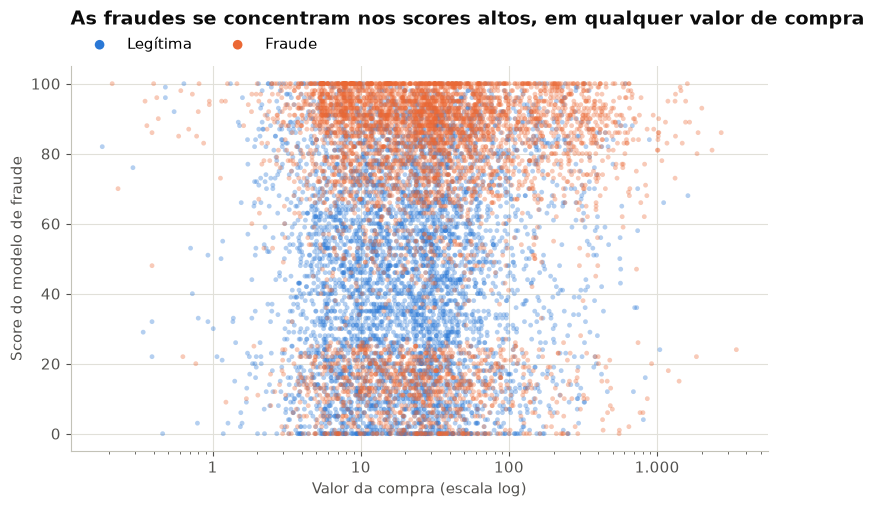

In [24]:
fig, ax = plt.subplots()
ax.grid(axis="x")                      # no scatter, grade nos dois eixos ajuda a ler

for status, cor in CORES_STATUS.items():
    pontos = amostra[amostra["status"] == status]
    ax.scatter(pontos["valor_compra"], pontos["score_fraude_modelo"],
               s=12, alpha=0.35, color=cor, edgecolors="none", label=status)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_eixo_log))
ax.set(title=TITULO_DISPERSAO, xlabel="Valor da compra (escala log)", ylabel="Score do modelo de fraude")

legenda = ax.legend(loc="lower left", ncols=2, bbox_to_anchor=(0, 1), markerscale=2)
for marcador in legenda.legend_handles:
    marcador.set_alpha(1)

plt.show()

### seaborn

| Personalização | Código | Efeito |
|---|---|---|
| Cor por grupo | `hue="status", palette=CORES_STATUS, hue_order=ORDEM_STATUS` | Legenda automática |
| Sem contorno | `linewidth=0` | No seaborn, o contorno do ponto é controlado por `linewidth` |
| Ordem de desenho | (vem da ordem das linhas do DataFrame) | Por isso ordenamos a `amostra` com as fraudes no fim |

> **Diferença sutil:** `hue_order` muda a ordem da **legenda**, mas **não** a ordem em que os pontos são desenhados. Quem decide quem fica por cima é a ordem das linhas.

**Variações úteis do seaborn:**
- `sns.regplot(...)`: adiciona a **reta de regressão** com faixa de confiança;
- `sns.jointplot(..., kind="hex")`: dispersão + histogramas nas margens, ou hexágonos de densidade para muitos pontos.

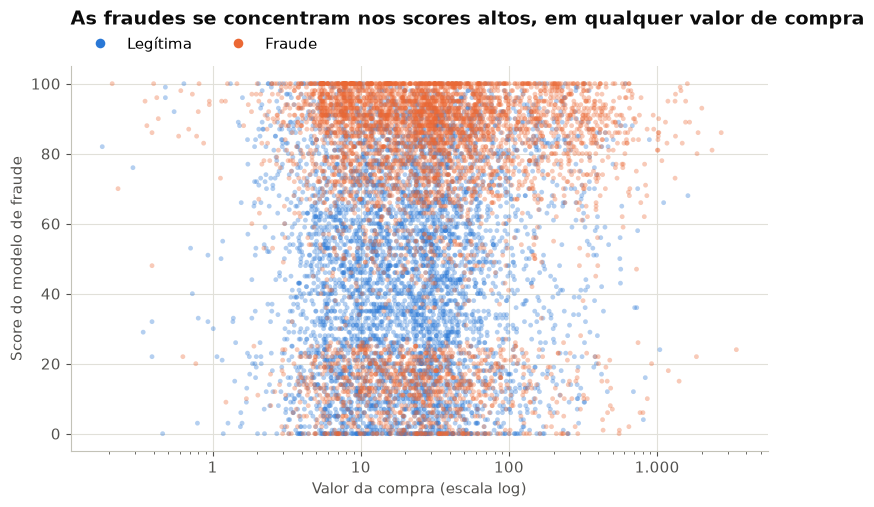

In [25]:
fig, ax = plt.subplots()
ax.grid(axis="x")

sns.scatterplot(
    data=amostra, x="valor_compra", y="score_fraude_modelo",
    hue="status", hue_order=ORDEM_STATUS, palette=CORES_STATUS,
    s=12, alpha=0.35, linewidth=0, ax=ax,
)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formatar_eixo_log))
ax.set(title=TITULO_DISPERSAO, xlabel="Valor da compra (escala log)", ylabel="Score do modelo de fraude")

legenda = ax.legend(title=None, loc="lower left", ncols=2, bbox_to_anchor=(0, 1), markerscale=2)
for marcador in legenda.legend_handles:
    marcador.set_alpha(1)

plt.show()

### plotly

O grande diferencial: **passe o mouse sobre um ponto e descubra qual compra é**. Na investigação de fraude, isso vale ouro.

| Personalização | Código | Efeito |
|---|---|---|
| Escala log | `log_x=True` | Equivalente a `set_xscale("log")` |
| Marcações do eixo log | `tickvals=VALORES_LOG, ticktext=TEXTOS_LOG` | Por padrão o plotly escreve "2" e "5" entre as potências de 10, poluindo o eixo |
| Transparência | `opacity=0.35` | Equivalente ao `alpha` |
| Tamanho do ponto | `marker_size=5` | Aqui é o **diâmetro em pixels** (no matplotlib, `s` é área) |
| Informação no hover | `hover_data={"produto_curto": True, "pais_agrupado": True}` | Colunas extras ao passar o mouse |
| Muitos pontos | `render_mode="webgl"` | Usa a placa de vídeo: aguenta centenas de milhares de pontos |

In [26]:
fig = px.scatter(
    amostra, x="valor_compra", y="score_fraude_modelo", color="status",
    color_discrete_map=CORES_STATUS,
    category_orders={"status": ORDEM_STATUS},
    log_x=True, opacity=0.35, render_mode="webgl",
    hover_data={"produto_curto": True, "pais_agrupado": True, "valor_compra": ":.2f", "status": False},
    labels={"valor_compra": "Valor da compra (escala log)", "score_fraude_modelo": "Score do modelo de fraude",
            "status": "", "produto_curto": "Produto", "pais_agrupado": "País"},
    title=TITULO_DISPERSAO,
)

fig.update_traces(marker=dict(size=5, line_width=0))
fig.update_xaxes(showgrid=True, gridcolor=COR_GRADE, tickvals=VALORES_LOG, ticktext=TEXTOS_LOG)
fig.update_layout(legend=dict(orientation="h", x=0, xanchor="left", y=1, yanchor="bottom",
                              itemsizing="constant"))   # legenda sem transparência

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Cor por grupo | Loop | `hue` | `color` |
| Tamanho do ponto | `s` = área (pt²) | `s` = área (pt²) | `size` = diâmetro (px) |
| Identificar um ponto | Não dá | Não dá | **Hover** com qualquer coluna |
| Extras prontos | `hexbin` | `regplot`, `jointplot`, `pairplot` | `trendline="ols"` (precisa do `statsmodels`), `marginal_x` |

**Escolha para dispersão:** seaborn para explorar relações (e o `pairplot` para várias variáveis de uma vez); plotly quando você precisa **identificar** pontos específicos.

**Leitura do exemplo:** as legítimas (azul) se espalham por toda a faixa de score; as fraudes (laranja) se acumulam acima de ~80, em qualquer valor de compra. O score separa bem, mas não perfeitamente: há fraudes com score baixo.

---
## 4. Heatmap (mapa de calor)

**Quando usar:** mostrar os valores de uma **matriz** por cor. Os usos clássicos:
- **matriz de correlação** entre variáveis numéricas;
- **tabela cruzada** de duas categóricas (ex.: dia da semana × hora, com a taxa de fraude em cada célula).

**Cuidados:**
- Correlação vai de −1 a +1: use uma escala **divergente** (duas cores + neutro no meio) e **fixe os limites** em −1 e +1. Sem isso, o "meio" da escala muda de gráfico para gráfico.
- Matriz de correlação é **espelhada**: mostre só um triângulo.
- Números dentro das células ajudam até ~12 × 12. Acima disso, só a cor.

**Exemplo:** correlação entre os scores, o valor da compra e a fraude.

### Preparando os dados

Usamos a correlação de **Spearman** em vez da de Pearson (o padrão do `.corr()`):

| | Pearson | Spearman |
|---|---|---|
| Mede | relação **linear** | relação **monotônica** (sobe junto / desce junto) |
| Outliers | muito sensível | resistente (usa a ordem dos valores) |

Vários scores (`score_3`, `score_5`, `score_6`) têm valores extremos, então Spearman é mais honesto aqui.

Para mostrar só o triângulo de baixo, **trocamos o triângulo de cima por `NaN`**. As três bibliotecas deixam células `NaN` em branco: o mesmo DataFrame serve para todas.

In [27]:
colunas_corr = ["valor_compra", "score_fraude_modelo"] + [f"score_{i}" for i in range(1, 11)] + ["fraude"]
correlacao = df[colunas_corr].corr(method="spearman")

# Máscara: True no triângulo de cima (incluindo a diagonal, que é sempre 1)
mascara = np.triu(np.ones(correlacao.shape, dtype=bool))
corr_triangulo = correlacao.mask(mascara)

# A 1ª linha e a última coluna ficaram 100% vazias: removemos
corr_triangulo = corr_triangulo.iloc[1:, :-1]

TITULO_HEATMAP = "Os scores se correlacionam em pares, mas nenhum, sozinho, explica a fraude"
LARGURA_QUADRADA, ALTURA_QUADRADA = 900, 760    # heatmap precisa de mais altura

corr_triangulo.round(2)

,valor_compra,score_fraude_modelo,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10
score_fraude_modelo,0.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_1,0.02,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_2,0.12,-0.02,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_3,0.22,-0.01,0.07,0.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_4,-0.02,-0.14,0.02,-0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score_5,-0.65,-0.06,0.27,-0.06,-0.08,0.00,NaN,NaN,NaN,NaN,NaN,NaN
score_6,-0.01,-0.22,-0.07,-0.06,-0.04,0.21,-0.08,NaN,NaN,NaN,NaN,NaN
score_7,-0.06,-0.03,0.07,-0.09,0.23,0.03,0.09,-0.01,NaN,NaN,NaN,NaN
score_8,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,NaN,NaN,NaN
score_9,0.01,-0.22,-0.03,-0.03,-0.02,0.08,-0.05,0.67,-0.02,0.0,NaN,NaN


### matplotlib

O matplotlib não tem uma função de heatmap: montamos com `pcolormesh` (uma grade de retângulos coloridos). É exatamente o que o seaborn faz por baixo dos panos.

| Personalização | Código | Efeito |
|---|---|---|
| Grade colorida | `ax.pcolormesh(valores, cmap=..., vmin=-1, vmax=1)` | Cada célula pintada pelo valor; limites fixos em ±1 |
| Células vazias | `np.ma.masked_invalid(...)` | Os `NaN` viram "máscara" e não são pintados |
| Respiro entre células | `edgecolors="white", linewidth=1.5` | Linhas brancas separando as células |
| Linha 0 no topo | `ax.invert_yaxis()` | Matrizes são lidas de cima para baixo |
| Rótulos centrados | `ax.set_xticks(np.arange(n) + 0.5, nomes)` | A célula *i* vai de *i* a *i+1*: o centro é *i+0,5* |
| Números nas células | loop com `ax.text(...)` | Texto branco em células escuras, preto nas claras |
| Barra de cores | `fig.colorbar(imagem, ...)` | Legenda da escala |

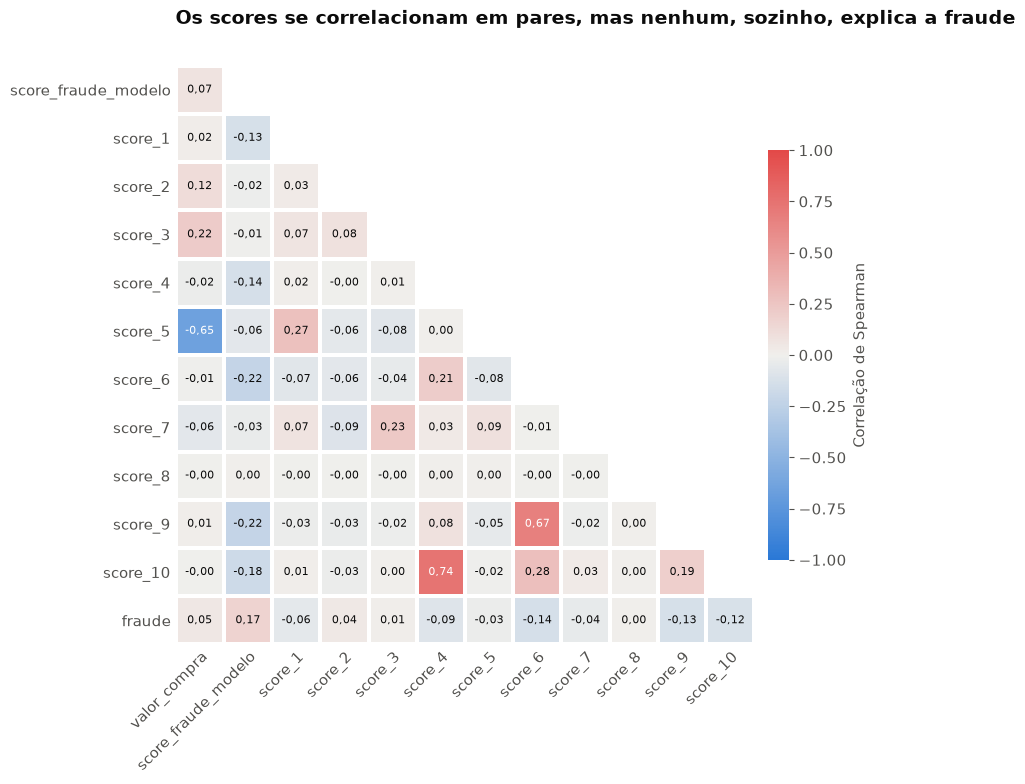

In [28]:
fig, ax = plt.subplots(figsize=(LARGURA_QUADRADA / DPI, ALTURA_QUADRADA / DPI))
ax.grid(False)
ax.spines[:].set_visible(False)

imagem = ax.pcolormesh(
    np.ma.masked_invalid(corr_triangulo.values),
    cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1,
    edgecolors="white", linewidth=1.5,
)
ax.invert_yaxis()
ax.set_aspect("equal")

n_linhas, n_colunas = corr_triangulo.shape
ax.set_xticks(np.arange(n_colunas) + 0.5, corr_triangulo.columns, rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(np.arange(n_linhas) + 0.5, corr_triangulo.index)
ax.tick_params(length=0)

for i in range(n_linhas):
    for j in range(n_colunas):
        valor = corr_triangulo.iloc[i, j]
        if pd.notna(valor):
            cor_texto = "white" if abs(valor) > 0.5 else TINTA_PRINCIPAL
            ax.text(j + 0.5, i + 0.5, formatar_numero(valor, 2), ha="center", va="center", fontsize=8, color=cor_texto)

barra = fig.colorbar(imagem, ax=ax, shrink=0.7, pad=0.02)
barra.set_label("Correlação de Spearman")
barra.outline.set_visible(False)
ax.set_title(TITULO_HEATMAP)

plt.show()

### seaborn

O `sns.heatmap` é a função mais usada do seaborn, e com razão: **uma chamada** faz tudo o que fizemos no matplotlib.

| Personalização | Código | Efeito |
|---|---|---|
| Limites e centro | `vmin=-1, vmax=1, center=0` | O cinza fica exatamente no zero |
| Números | `annot=True, fmt=".2f"` | Valor em cada célula. Aqui passamos um DataFrame de textos para usar vírgula decimal (`fmt=""`) |
| Cor do texto | (automática) | O seaborn escolhe branco ou preto conforme o fundo |
| Respiro | `linewidths=1.5, linecolor="white"` | Linhas brancas entre as células |
| Células quadradas | `square=True` | |
| Barra de cores | `cbar_kws={"shrink": 0.7, "label": "..."}` | Repassa opções para o `colorbar` do matplotlib |
| Triângulo | `mask=...` | Alternativa ao `NaN`: o seaborn aceita a máscara direto |

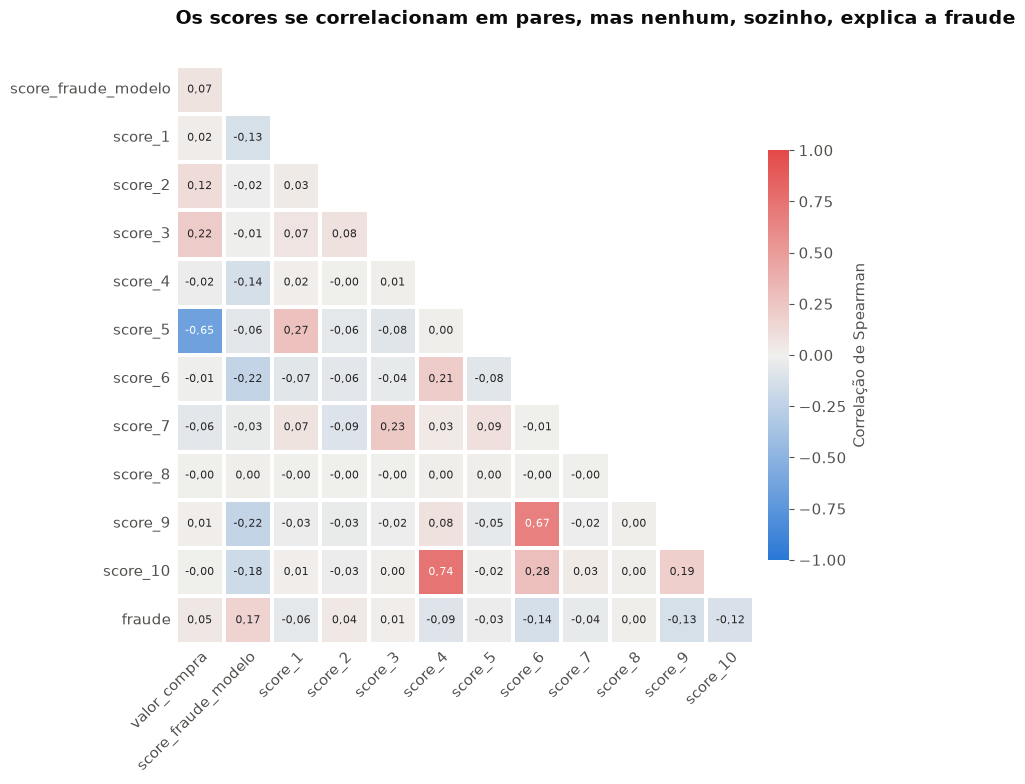

In [29]:
fig, ax = plt.subplots(figsize=(LARGURA_QUADRADA / DPI, ALTURA_QUADRADA / DPI))
ax.grid(False)          # sem isso, a grade do tema aparece no triângulo vazio

textos =corr_triangulo.map(lambda v: formatar_numero(v, 2) if pd.notna(v) else "")

sns.heatmap(
    corr_triangulo,
    cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1, center=0,
    annot=textos, fmt="", annot_kws={"size": 8},
    linewidths=1.5, linecolor="white", square=True,
    cbar_kws={"shrink": 0.7, "pad": 0.02, "label": "Correlação de Spearman"},
    ax=ax,
)

ax.tick_params(length=0)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_title(TITULO_HEATMAP)

plt.show()

### plotly

`px.imshow` desenha qualquer matriz. O hover mostra o par de variáveis e o valor, prático em matrizes grandes, onde números nas células ficariam ilegíveis.

| Personalização | Código | Efeito |
|---|---|---|
| Escala e limites | `color_continuous_scale=ESCALA_DIVERGENTE_PLOTLY, zmin=-1, zmax=1` | Mesmo papel de `cmap`, `vmin`, `vmax` |
| Números | `text_auto=".2f"` | Valor em cada célula (com vírgula, graças ao `separators` do template) |
| Respiro | `xgap=1.5, ygap=1.5` | Espaço entre as células |
| Hover | `hovertemplate="%{y} × %{x}<br>ρ = %{z:.2f}"` | Par de variáveis + valor |
| Células quadradas | `aspect="equal"` | |

In [30]:
fig = px.imshow(
    corr_triangulo,
    color_continuous_scale=ESCALA_DIVERGENTE_PLOTLY, zmin=-1, zmax=1,
    text_auto=".2f", aspect="equal",
    labels={"color": "Correlação<br>de Spearman"},
    title=TITULO_HEATMAP,
)

fig.update_traces(xgap=1.5, ygap=1.5, textfont_size=10,
                  hovertemplate="%{y} × %{x}<br>ρ = %{z:.2f}<extra></extra>")
fig.update_xaxes(tickangle=-45, showline=False, ticks="")
fig.update_yaxes(showgrid=False, showline=False)
fig.update_layout(width=LARGURA_QUADRADA, height=ALTURA_QUADRADA,
                  coloraxis_colorbar=dict(len=0.7, thickness=16))

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Função pronta | Não (`pcolormesh` / `imshow` + loop para os números) | **`sns.heatmap`** | `px.imshow` |
| Cor do texto automática | Não | Sim | Sim |
| Triângulo | `NaN` + `masked_invalid` | `NaN` ou `mask=` | `NaN` |
| Matriz grande | Ilegível | Ilegível | Hover resolve |

**Escolha para heatmap:** seaborn, sem discussão, para relatórios e análise. Plotly quando a matriz for grande demais para números nas células.

**Leitura do exemplo:** os pares mais fortes são `score_4` × `score_10` (0,74), `score_6` × `score_9` (0,67) e `valor_compra` × `score_5` (−0,65, inversa: quanto maior o valor, menor o `score_5`). Esses pares provavelmente medem coisas parecidas. Na última linha, nenhuma variável tem correlação forte com `fraude` (a maior é a do `score_fraude_modelo`, 0,17). Isso é esperado num evento raro e mostra por que a fraude é detectada **combinando** variáveis.

---
## 5. Boxplot

**Quando usar:** comparar a **distribuição** de uma variável numérica entre grupos, de forma resumida, e localizar **outliers**.

Como ler a caixa:

| Elemento | Significado |
|---|---|
| Linha do meio | **mediana** (50% dos valores abaixo) |
| Caixa | do 1º quartil (25%) ao 3º quartil (75%): os 50% centrais |
| Bigodes | até o valor mais extremo dentro de **1,5 × a altura da caixa** |
| Pontos soltos | **outliers**: além dos bigodes |

**Cuidados:**
- A caixa **esconde a forma** da distribuição: dois picos (bimodal) ficam invisíveis. Veja o violino na próxima seção.
- Público leigo nem sempre sabe ler quartis: explique ou prefira barras com a mediana.
- Com escala log, todas as bibliotecas devem calcular os quartis **nos valores originais**. Veja a nota no seaborn.

**Exemplo:** valor da compra por país, separando fraudes e legítimas (amostra balanceada).

In [31]:
TITULO_BOXPLOT = "Em todos os países, a fraude típica é mais cara que a compra legítima"

(amostra.groupby(["pais_agrupado", "status"])["valor_compra"]
        .median()
        .unstack()
        .loc[ORDEM_PAIS, ORDEM_STATUS]
        .round(2))

status,Legítima,Fraude
pais_agrupado,,
BR,18.68,24.16
AR,28.85,40.77
Outros,19.09,33.83


### matplotlib

Como nas barras, **não há boxplot agrupado pronto**: chamamos `ax.boxplot` uma vez por status, com `positions` deslocadas.

| Personalização | Código | Efeito |
|---|---|---|
| Caixas coloridas | `patch_artist=True` + `boxprops=dict(facecolor=cor)` | Sem `patch_artist`, a caixa é só um contorno |
| Mediana visível | `medianprops=dict(color="white", linewidth=2)` | Linha branca destacada sobre a cor |
| Outliers discretos | `flierprops=dict(marker="o", markersize=3, alpha=0.4, ...)` | Pontos pequenos e transparentes |
| Posições | `positions=np.arange(3) + deslocamento` | Caixas lado a lado |
| Legenda | `Patch(facecolor=cor, label=status)` | O `boxplot` não cria legenda: montamos à mão |

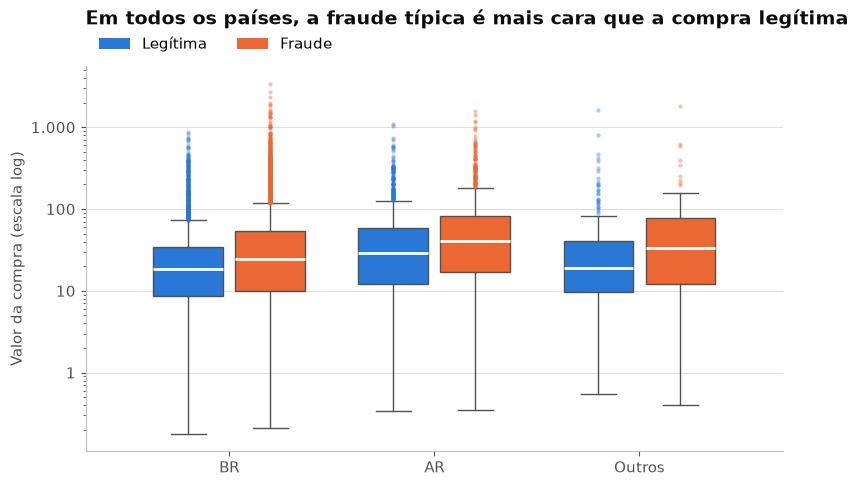

In [32]:
fig, ax = plt.subplots()

for i, (status, cor) in enumerate(CORES_STATUS.items()):
    grupos = [amostra.loc[(amostra["pais_agrupado"] == pais) & (amostra["status"] == status), "valor_compra"]
              for pais in ORDEM_PAIS]
    ax.boxplot(
        grupos,
        positions=np.arange(len(ORDEM_PAIS)) + (i - 0.5) * 0.4,
        widths=0.34,
        patch_artist=True,
        boxprops=dict(facecolor=cor, edgecolor=TINTA_SECUNDARIA, linewidth=1),
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=TINTA_SECUNDARIA, linewidth=1),
        capprops=dict(color=TINTA_SECUNDARIA, linewidth=1),
        flierprops=dict(marker="o", markersize=3, markerfacecolor=cor, markeredgecolor="none", alpha=0.4),
    )

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_eixo_log))
ax.set_xticks(np.arange(len(ORDEM_PAIS)), ORDEM_PAIS)
ax.set(title=TITULO_BOXPLOT, xlabel="", ylabel="Valor da compra (escala log)")
ax.legend(handles=[Patch(facecolor=cor, label=status) for status, cor in CORES_STATUS.items()],
          loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

### seaborn

| Personalização | Código | Efeito |
|---|---|---|
| Agrupamento | `hue="status"` | Caixas lado a lado, automaticamente |
| Respiro | `gap=0.1` | Vão entre as caixas do mesmo grupo |
| Linhas | `linecolor=..., linewidth=1` | Cor do contorno, bigodes e outliers (os outliers ficam na cor da linha, não na do grupo) |
| Cores fiéis | `saturation=1` | Desliga o "desbotamento" padrão de 75% |
| Mediana | `medianprops=...` | Repassa as mesmas opções do matplotlib |
| Escala log | `ax.set_yscale("log")` **depois** do boxplot | Veja a nota abaixo |

> **Nota sobre escala log:** o seaborn tem o atalho `log_scale=True`, mas ele **calcula os quartis e os bigodes nos valores já em log**. Os bigodes mudam de tamanho e os outliers também. Para comparar com o matplotlib e o plotly (que calculam nos valores originais), usamos `ax.set_yscale("log")` depois: só a **visualização** fica em log.

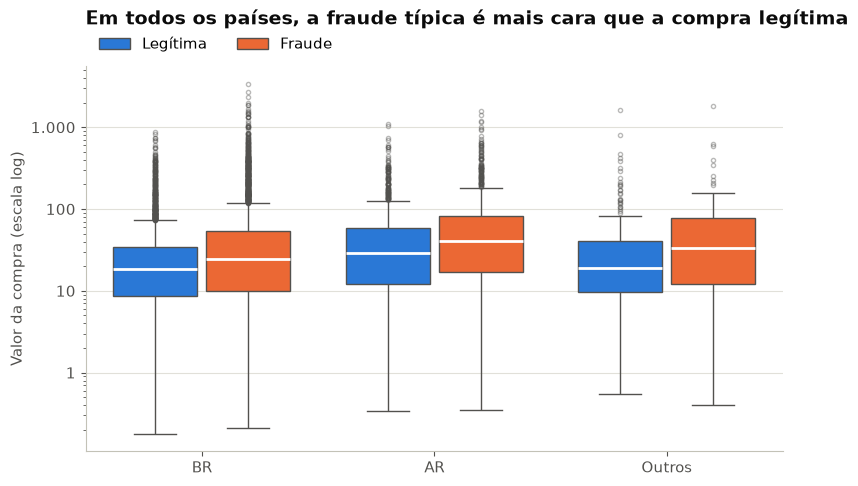

In [33]:
fig, ax = plt.subplots()

sns.boxplot(
    data=amostra, x="pais_agrupado", y="valor_compra",
    hue="status", hue_order=ORDEM_STATUS, palette=CORES_STATUS, order=ORDEM_PAIS,
    width=0.8, gap=0.1, linecolor=TINTA_SECUNDARIA, linewidth=1, saturation=1,
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
    ax=ax,
)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_eixo_log))
ax.set(title=TITULO_BOXPLOT, xlabel="", ylabel="Valor da compra (escala log)")
ax.legend(title=None, loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

### plotly

| Personalização | Código | Efeito |
|---|---|---|
| Agrupamento | `color="status"` (o padrão é `boxmode="group"`) | Caixas lado a lado |
| Outliers | `points="outliers"` | Também aceita `"all"` (todos os pontos ao lado da caixa) e `False` |
| Escala log | `log_y=True` | Quartis calculados nos valores originais |
| Marcações do eixo log | `tickvals=VALORES_LOG, ticktext=TEXTOS_LOG` | Só as potências de 10, como no matplotlib |
| Hover | (automático) | Mostra mín., Q1, mediana, Q3, máx. e outliers com o valor exato |
| Respiro | `boxgap`, `boxgroupgap` | Espaço entre países e entre as caixas do país |

> **Limitação:** o plotly não permite colorir a linha da **mediana** separadamente do contorno da caixa. Por isso a caixa fica semitransparente: assim a mediana (na cor da borda) continua visível.

In [34]:
fig = px.box(
    amostra, x="pais_agrupado", y="valor_compra", color="status",
    color_discrete_map=CORES_STATUS,
    category_orders={"status": ORDEM_STATUS, "pais_agrupado": ORDEM_PAIS},
    log_y=True, points="outliers",
    labels={"pais_agrupado": "", "valor_compra": "Valor da compra (escala log)", "status": ""},
    title=TITULO_BOXPLOT,
)

fig.update_traces(line_width=1.5, marker=dict(size=3, opacity=0.4))
fig.update_yaxes(tickvals=VALORES_LOG, ticktext=TEXTOS_LOG)
fig.update_layout(boxgap=0.2, boxgroupgap=0.12,
                  legend=dict(orientation="h", x=0, xanchor="left", y=1, yanchor="bottom"))

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Boxplot agrupado | Manual (`positions`) | Automático (`hue`) | Automático (`color`) |
| Legenda | Manual (`Patch`) | Automática | Automática |
| Destacar a mediana | `medianprops` | `medianprops` | Não dá separado |
| Escala log | Quartis nos valores originais | `log_scale=True` calcula em log (cuidado) | Quartis nos valores originais |
| Ver os números exatos | Não | Não | Hover mostra Q1, mediana, Q3 |

**Escolha para boxplot:** seaborn. Plotly quando o público quiser ler os quartis exatos passando o mouse.

**Leitura do exemplo:** em todos os países a mediana do valor das fraudes é maior que a das legítimas (BR: 24 contra 19; AR: 41 contra 29). Mas as caixas se sobrepõem muito: o valor, sozinho, não separa fraude de compra legítima. Os muitos outliers no topo mostram uma distribuição bem assimétrica: poucas compras muito caras.

---
## 6. Gráfico de violino

**Quando usar:** mesma pergunta do boxplot (distribuição por grupo), mas mostrando a **forma** da distribuição: onde os valores se acumulam, se há dois picos, se é simétrica.

A largura do violino em cada altura é uma **estimativa de densidade** (KDE): mais largo = mais valores ali. Com o violino **dividido** (`split`), cada metade mostra um grupo, o que facilita a comparação lado a lado.

**Cuidados:**
- O KDE **suaviza** os dados: com poucos pontos (< ~50 por grupo), ele inventa formas. Mostre os pontos junto ou use outro gráfico.
- Por padrão, o KDE "vaza" para além dos dados (por exemplo, score negativo). Corte no intervalo real dos dados (`cut=0` no seaborn, `spanmode="hard"` no plotly).
- Quando a variável tem limites (0 a 100), o KDE perto das bordas é menos confiável.

**Exemplo:** score do modelo por país, com legítimas à esquerda e fraudes à direita.

### Ajustes para a comparação ser justa

As três bibliotecas têm padrões diferentes para o violino. Alinhamos assim:

| Ajuste | matplotlib | seaborn | plotly |
|---|---|---|---|
| Corte nos dados reais | já é o padrão | `cut=0` | `spanmode="hard"` |
| Mesma largura máxima para todos | já é o padrão | `density_norm="width"` | `scalemode="width"` (padrão) |
| Metades | `side="low"` / `"high"` (matplotlib ≥ 3.9) | `split=True` | `side="negative"` / `"positive"` |

In [35]:
TITULO_VIOLINO = "As fraudes têm dois picos de score: acima de 80 e perto de 20"

(amostra.groupby(["pais_agrupado", "status"])["score_fraude_modelo"]
        .quantile([0.25, 0.5, 0.75])
        .unstack()
        .loc[ORDEM_PAIS])

0.25  0.50  0.75
pais_agrupado status                    
BR            Fraude    59.0  84.0  93.0
              Legítima  22.0  44.0  68.0
AR            Fraude    25.0  87.0  96.0
              Legítima  23.0  52.0  85.0
Outros        Fraude    45.5  83.0  92.0
              Legítima  23.0  48.0  67.0

### matplotlib

| Personalização | Código | Efeito |
|---|---|---|
| Meio violino | `side="low"` (esquerda) e `side="high"` (direita) | Disponível a partir do matplotlib 3.9 |
| Quartis | `quantiles=[[0.25, 0.5, 0.75]] * 3` | Uma lista de quantis por violino |
| Esconder extremos | `showextrema=False` | Remove as linhas de mínimo e máximo |
| Cor do corpo | `partes["bodies"]` → `set_facecolor`, `set_alpha` | O `violinplot` devolve um dicionário com as partes do desenho |
| Cor das linhas de quartil | `partes["cquantiles"].set_color(...)` | |

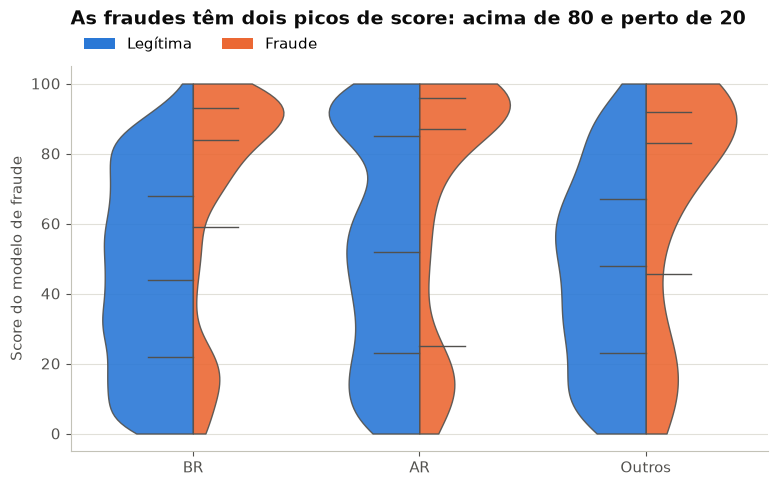

In [36]:
fig, ax = plt.subplots()
posicoes = np.arange(len(ORDEM_PAIS))

for status, lado in [("Legítima", "low"), ("Fraude", "high")]:
    grupos = [amostra.loc[(amostra["pais_agrupado"] == pais) & (amostra["status"] == status), "score_fraude_modelo"]
              for pais in ORDEM_PAIS]
    partes = ax.violinplot(
        grupos, positions=posicoes, widths=0.8, side=lado,
        showextrema=False, quantiles=[[0.25, 0.5, 0.75]] * len(ORDEM_PAIS),
    )
    for corpo in partes["bodies"]:
        corpo.set_facecolor(CORES_STATUS[status])
        corpo.set_edgecolor(TINTA_SECUNDARIA)
        corpo.set_linewidth(1)
        corpo.set_alpha(0.9)
    partes["cquantiles"].set_color(TINTA_SECUNDARIA)
    partes["cquantiles"].set_linewidth(1)

ax.set_xticks(posicoes, ORDEM_PAIS)
ax.set_ylim(-5, 105)
ax.set(title=TITULO_VIOLINO, xlabel="", ylabel="Score do modelo de fraude")
ax.legend(handles=[Patch(facecolor=cor, label=status) for status, cor in CORES_STATUS.items()],
          loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

### seaborn

| Personalização | Código | Efeito |
|---|---|---|
| Violino dividido | `hue="status", split=True` | Metade para cada grupo |
| Linhas internas | `inner="quart"` | Linhas nos quartis (alternativas: `"box"`, `"point"`, `"stick"`, `None`) |
| Corte | `cut=0` | Não estende o KDE além dos dados reais |
| Largura | `density_norm="width"` | Todos os violinos com a mesma largura máxima |
| Suavização | `bw_adjust=1` | Menor = mais detalhado (e ruidoso); maior = mais suave |
| Cores fiéis | `saturation=1` | Desliga o "desbotamento" padrão de 75% |
| Ver os pontos | `sns.stripplot(..., dodge=True, alpha=0.2)` por cima | Útil quando há poucos dados |

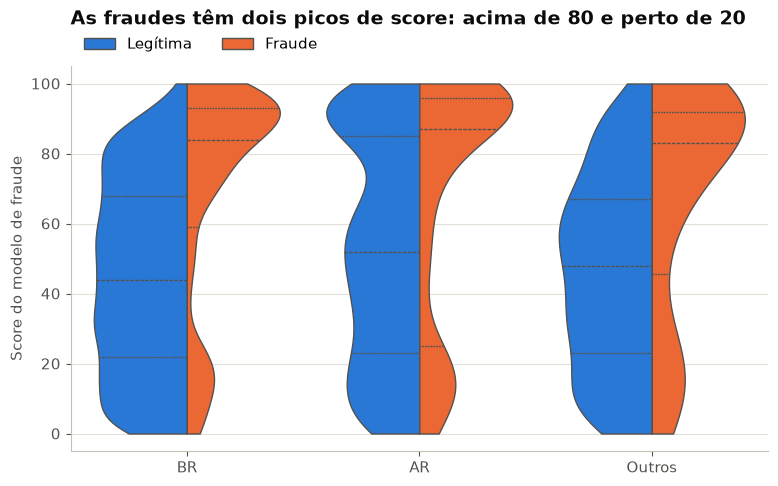

In [37]:
fig, ax = plt.subplots()

sns.violinplot(
    data=amostra, x="pais_agrupado", y="score_fraude_modelo",
    hue="status", hue_order=ORDEM_STATUS, palette=CORES_STATUS, order=ORDEM_PAIS,
    split=True, inner="quart", cut=0, density_norm="width", bw_adjust=1,
    width=0.8, linecolor=TINTA_SECUNDARIA, linewidth=1, saturation=1,
    ax=ax,
)

ax.set_ylim(-5, 105)
ax.set(title=TITULO_VIOLINO, xlabel="", ylabel="Score do modelo de fraude")
ax.legend(title=None, loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

### plotly

O `px.violin` não tem `split`. Fazemos a divisão dizendo para cada trace (um por status) **de que lado** desenhar.

| Personalização | Código | Efeito |
|---|---|---|
| Sobrepor os dois grupos | `violinmode="overlay"` | Os dois violinos de um país ocupam a mesma posição... |
| ...cada um de um lado | `fig.for_each_trace(lambda t: t.update(side=...))` | ...e cada um desenha só uma metade |
| Corte | `spanmode="hard"` | Equivalente ao `cut=0` |
| Cor do corpo | `fillcolor=CORES_STATUS[t.name]` | **Armadilha:** ao mudar `line_color`, o corpo do violino herda essa cor (fica tudo cinza). Informe `fillcolor` explicitamente |
| Quartis | `box_visible=True`, `box_width=0.15` | Não há `inner="quart"`; a alternativa é uma mini caixa dentro |
| Hover | (automático) | Mostra mediana, quartis e o KDE na altura do mouse |

In [38]:
fig = px.violin(
    amostra, x="pais_agrupado", y="score_fraude_modelo", color="status",
    color_discrete_map=CORES_STATUS,
    category_orders={"status": ORDEM_STATUS, "pais_agrupado": ORDEM_PAIS},
    labels={"pais_agrupado": "", "score_fraude_modelo": "Score do modelo de fraude", "status": ""},
    title=TITULO_VIOLINO,
)

fig.update_traces(spanmode="hard", points=False, width=0.8, line_width=1, line_color=TINTA_SECUNDARIA,
                  box_visible=True, box_width=0.15, box_fillcolor="white", box_line_width=1)
# Lado e cor de cada metade. A cor precisa vir DEPOIS do line_color: o plotly usa a cor da linha
# para pintar o corpo quando fillcolor não é informado
fig.for_each_trace(lambda t: t.update(side="negative" if t.name == "Legítima" else "positive",
                                      fillcolor=CORES_STATUS[t.name], opacity=0.9))
fig.update_yaxes(range=[-5, 105])
fig.update_layout(violinmode="overlay", violingap=0.2,
                  legend=dict(orientation="h", x=0, xanchor="left", y=1, yanchor="bottom"))

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Violino dividido | `side=` + loop | **`split=True`** | `side=` + `violinmode="overlay"` |
| Linhas de quartil | `quantiles=` | `inner="quart"` | Só mini caixa (`box_visible`) |
| Legenda | Manual | Automática | Automática |
| Padrões que enganam | Poucos | `cut=2` estende além dos dados | `spanmode="soft"` estende além dos dados |

**Escolha para violino:** seaborn (o `split=True` é imbatível). Em qualquer biblioteca, confira o corte nos dados reais.

**Leitura do exemplo:** em todos os países, a metade laranja (fraudes) tem **dois picos**: o principal acima de 80 e um segundo, menor, **perto de 20**. Na **AR** esse segundo pico é o mais forte: um quarto das fraudes argentinas tem score abaixo de 25. Um boxplot mostraria só uma caixa mais larga, sem revelar esse segundo grupo de fraudes que o modelo não pega. Repare também nas legítimas da AR: elas têm um pico **acima de 90**, ou seja, o modelo dá score alto para muitas compras legítimas argentinas.

---
## 7. Histograma

**Quando usar:** ver como **uma** variável numérica se distribui: onde se concentra, se é simétrica, se tem caudas longas ou vários picos.

O histograma divide o eixo em **faixas** (*bins*) e conta quantos valores caem em cada uma.

**Cuidados:**
- O **número de faixas muda a leitura**: poucas escondem detalhes, muitas criam ruído. Teste alguns valores.
- Para comparar grupos de **tamanhos diferentes**, normalize: mostre a **% do grupo** em cada faixa, não a contagem. Sem isso, o grupo maior domina o gráfico.
- Use **as mesmas faixas** para todos os grupos e em todas as bibliotecas.

**Exemplo:** distribuição do score do modelo, legítimas × fraudes.

### Faixas idênticas nas três bibliotecas

Cada biblioteca escolhe as faixas de um jeito. Para garantir o mesmo gráfico, definimos as faixas **explicitamente**: de 5 em 5 pontos, de 0 a 105.

> **Por que até 105?** O score vai até 100. O plotly fecha as faixas à esquerda, `[95, 100)`: o valor 100 cairia fora. Com uma faixa extra `[100, 105)`, as três bibliotecas contam o 100 no mesmo lugar. Essa última barra mostra os scores **exatamente 100**, e ela é alta nas fraudes.

In [39]:
FAIXAS = np.arange(0, 110, 5)    # [0, 5, 10, ..., 100, 105]
TITULO_HISTOGRAMA = "Legítimas se espalham por todo o score; fraudes se acumulam acima de 80"

pd.crosstab(pd.cut(amostra["score_fraude_modelo"], FAIXAS, right=False), amostra["status"], normalize="columns").tail(5).round(3)

status,Fraude,Legítima
score_fraude_modelo,,
"[80, 85)",0.075,0.050
"[85, 90)",0.122,0.046
"[90, 95)",0.167,0.040
"[95, 100)",0.133,0.021
"[100, 105)",0.081,0.010


### matplotlib

| Personalização | Código | Efeito |
|---|---|---|
| Faixas fixas | `bins=FAIXAS` | Mesmas bordas nas três bibliotecas |
| % do grupo | `weights=np.full(n, 100 / n)` | Cada valor "pesa" 100/n: a soma das barras de cada grupo dá 100% |
| Sobreposição | `alpha=0.55` | Vê-se as duas distribuições ao mesmo tempo |
| Contorno | `edgecolor="white", linewidth=0.8` | Separa visualmente as barras |

> Existe também `density=True`, que faz a **área** somar 1 (eixo y vira "densidade"). Percentual é mais fácil de explicar.

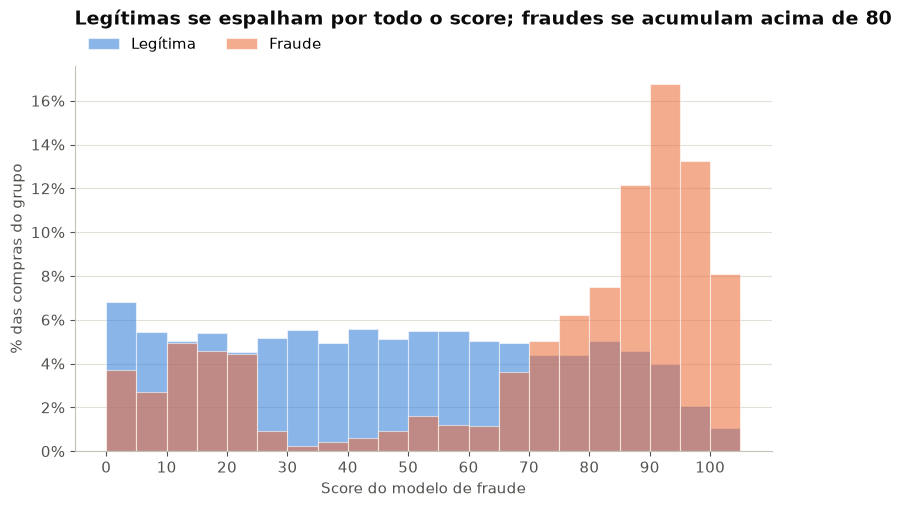

In [40]:
fig, ax = plt.subplots()

for status, cor in CORES_STATUS.items():
    valores = amostra.loc[amostra["status"] == status, "score_fraude_modelo"]
    ax.hist(valores, bins=FAIXAS, weights=np.full(len(valores), 100 / len(valores)),
            color=cor, alpha=0.55, edgecolor="white", linewidth=0.8, label=status)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_xticks(np.arange(0, 101, 10))
ax.set(title=TITULO_HISTOGRAMA, xlabel="Score do modelo de fraude", ylabel="% das compras do grupo")
ax.legend(loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

### seaborn

| Personalização | Código | Efeito |
|---|---|---|
| % do grupo | `stat="percent", common_norm=False` | **`common_norm=False` é essencial**: cada grupo soma 100% sozinho. Com `True` (padrão), os dois somam 100% juntos |
| Faixas fixas | `bins=FAIXAS` | |
| Estilo | `element="bars"` | Também: `"step"` (só o contorno, ótimo para sobrepor) e `"poly"` |
| Curva de densidade | `kde=True` | Recurso exclusivo: suaviza o histograma numa curva |
| Empilhar | `multiple="stack"` | Ou `"dodge"` (lado a lado), `"fill"` (proporção) |

> **Armadilha da sobreposição:** com barras transparentes, **quem é desenhado por último fica por cima** e a cor da área sobreposta muda. O matplotlib e o plotly desenham na ordem da lista (Legítima, depois Fraude por cima). O seaborn desenha **ao contrário** do `hue_order`. Para os três ficarem iguais, invertemos o `hue_order` (`ORDEM_STATUS[::-1]`) e montamos a legenda à mão, na ordem certa.

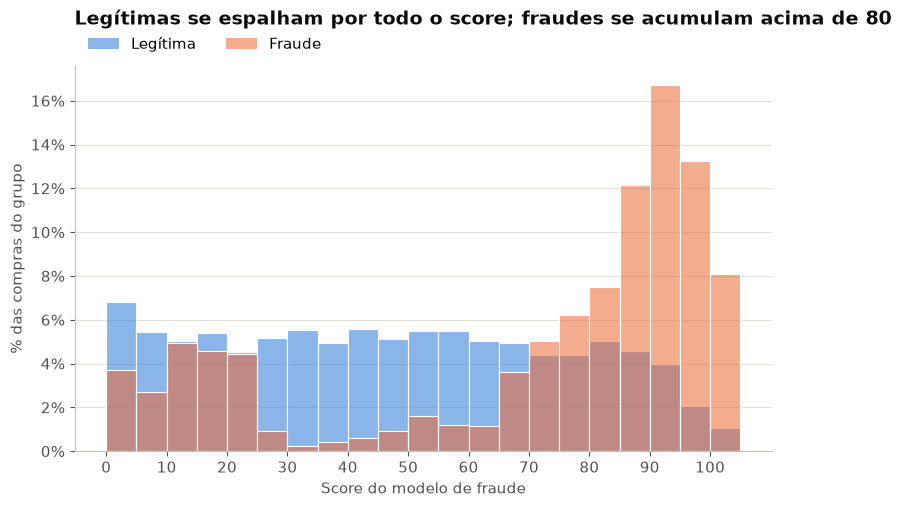

In [41]:
fig, ax = plt.subplots()

sns.histplot(
    data=amostra, x="score_fraude_modelo",
    hue="status", hue_order=ORDEM_STATUS[::-1], palette=CORES_STATUS,   # invertido: ver a nota acima
    bins=FAIXAS, stat="percent", common_norm=False,
    element="bars", alpha=0.55, edgecolor="white", linewidth=0.8,
    legend=False, ax=ax,
)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_xticks(np.arange(0, 101, 10))
ax.set(title=TITULO_HISTOGRAMA, xlabel="Score do modelo de fraude", ylabel="% das compras do grupo")
ax.legend(handles=[Patch(facecolor=cor, alpha=0.55, label=status) for status, cor in CORES_STATUS.items()],
          loc="lower left", ncols=2, bbox_to_anchor=(0, 1))

plt.show()

### plotly

| Personalização | Código | Efeito |
|---|---|---|
| % do grupo | `histnorm="percent"` | Normaliza cada trace (grupo) separadamente |
| Sobreposição | `barmode="overlay"`, `opacity=0.55` | O padrão do plotly é empilhar |
| Faixas fixas | `xbins=dict(start=0, end=105, size=5)` | Equivalente ao `bins=FAIXAS` |
| Hover | (automático) | Mostra a faixa (ex.: `80-84`) e o percentual |
| Gráfico na margem | `marginal="box"` ou `"violin"` | Adiciona um boxplot/violino acima do histograma |

In [42]:
fig = px.histogram(
    amostra, x="score_fraude_modelo", color="status",
    color_discrete_map=CORES_STATUS,
    category_orders={"status": ORDEM_STATUS},
    histnorm="percent", barmode="overlay", opacity=0.55,
    labels={"score_fraude_modelo": "Score do modelo de fraude", "status": ""},
    title=TITULO_HISTOGRAMA,
)

fig.update_traces(xbins=dict(start=0, end=105, size=5), marker_line_color="white", marker_line_width=0.8,
                  hovertemplate="Score %{x}<br>%{y:.1f}% do grupo<extra></extra>")
fig.update_xaxes(dtick=10)
fig.update_yaxes(title_text="% das compras do grupo", ticksuffix="%")
fig.update_layout(bargap=0, legend=dict(orientation="h", x=0, xanchor="left", y=1, yanchor="bottom"))

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Normalizar por grupo | Manual (`weights`) | `stat="percent", common_norm=False` | `histnorm="percent"` |
| Curva de densidade | Manual (`scipy`) | **`kde=True`** | `figure_factory.create_distplot` |
| Faixa de 100 | Fecha a última faixa à direita | Igual ao matplotlib | Fecha à esquerda: cuidado com valores na borda |
| Extras | | `multiple="stack"/"fill"` | `marginal="box"` |

**Escolha para histograma:** seaborn (normalização por grupo e KDE em um parâmetro). Fique atento à **forma de fechar as faixas** quando trocar de biblioteca.

**Leitura do exemplo:** as compras legítimas se espalham quase por igual entre 0 e 90 (4% a 6% em cada faixa). As fraudes sobem a partir de ~70, e cerca de 8% delas têm score **exatamente 100** (a barra da direita). O segundo pico de fraudes visto no violino aparece aqui na faixa de 0 a 25: um "vale" entre 25 e 65 separa os dois grupos.

---
## 8. Gráfico de pizza (e rosca)

**Quando usar:** mostrar como **um todo se divide** em poucas partes, quando a mensagem é "quanto cada parte representa do total".

**Cuidados:**
- **Máximo de 3 a 5 fatias.** Agrupe o resto em "Outros".
- O olho humano compara **ângulos** muito pior do que **comprimentos**: se as fatias têm tamanhos parecidos, use barras.
- Escreva o percentual nas fatias.
- A **rosca** (*donut*) deixa o centro livre para o total.
- Comece às 12h e siga no sentido horário, do maior para o menor.

**Exemplo:** participação de cada país no total de compras. São só 3 fatias, com tamanhos bem diferentes: um caso adequado para pizza.

> **O seaborn não tem gráfico de pizza** (por decisão de projeto: os autores consideram que barras comunicam melhor). Na seção do seaborn mostramos a **alternativa recomendada**: barra de 100%.

In [43]:
participacao = (
    df["pais_agrupado"].value_counts()
      .reindex(ORDEM_PAIS)
      .rename_axis("pais")
      .reset_index(name="compras")
)
participacao["percentual"] = participacao["compras"] / participacao["compras"].sum() * 100

TOTAL_COMPRAS = participacao["compras"].sum()
TITULO_PIZZA = "3 em cada 4 compras vêm do Brasil"

participacao

,pais,compras,percentual
0,BR,111628,74.418667
1,AR,31964,21.309333
2,Outros,6408,4.272000


### matplotlib

| Personalização | Código | Efeito |
|---|---|---|
| Rosca | `wedgeprops=dict(width=0.42)` | Largura do anel (1 = pizza cheia) |
| Respiro entre fatias | `wedgeprops=dict(edgecolor="white", linewidth=2)` | Linha branca entre as fatias |
| Começar às 12h, sentido horário | `startangle=90, counterclock=False` | |
| Rótulos | `labels=[...]`, `labeldistance=1.12` | Nome + % fora da rosca |
| Total no centro | `ax.text(0, 0, ...)` | O centro da pizza é a coordenada (0, 0) |
| Proporção correta | `ax.set_aspect("equal")` | Círculo, não elipse |

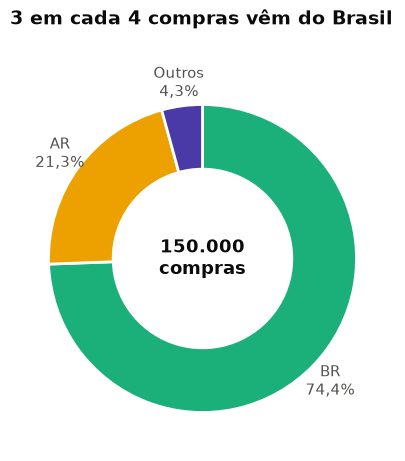

In [44]:
fig, ax = plt.subplots()
ax.grid(False)

rotulos = [f"{pais}\n{formatar_numero(pct, 1)}%" for pais, pct in zip(participacao["pais"], participacao["percentual"])]

ax.pie(
    participacao["compras"],
    labels=rotulos, labeldistance=1.15,
    colors=[CORES_PAIS[p] for p in participacao["pais"]],
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    textprops=dict(color=TINTA_SECUNDARIA, fontsize=11, ha="center"),
)

ax.text(0, 0, f"{formatar_numero(TOTAL_COMPRAS)}\ncompras", ha="center", va="center",
        fontsize=13, fontweight="bold", color=TINTA_PRINCIPAL)
ax.set_aspect("equal")
ax.set_title(TITULO_PIZZA)

plt.show()

### seaborn: a alternativa sem pizza

Uma **barra horizontal**, com as fatias lado a lado, mostra a mesma divisão do todo. E comprimentos são mais fáceis de comparar do que ângulos.

O seaborn não tem barra empilhada para dados já agregados. Então usamos o `sns.histplot` com `multiple="fill"` e `weights`: cada país "pesa" o seu número de compras e o `fill` transforma tudo em proporção.

| Personalização | Código | Efeito |
|---|---|---|
| Barra única de 100% | `y="barra"` (coluna com um único valor), `weights="compras"`, `multiple="fill"` | Uma barra, dividida pela proporção de cada país |
| Ordem dos pedaços | `hue_order=ORDEM_PAIS[::-1]` | **Armadilha:** o seaborn empilha a partir do **último** grupo. Invertendo a lista, o BR fica à esquerda |
| Rótulos dentro | `ax.text(...)` no centro de cada pedaço | % escrito direto na fatia (dispensa a legenda) |
| Pedaço pequeno | rótulo **abaixo** da barra (`transform=ax.get_xaxis_transform()`) | Com `transform`, o y vira fração do eixo: −0,08 = logo abaixo da barra |

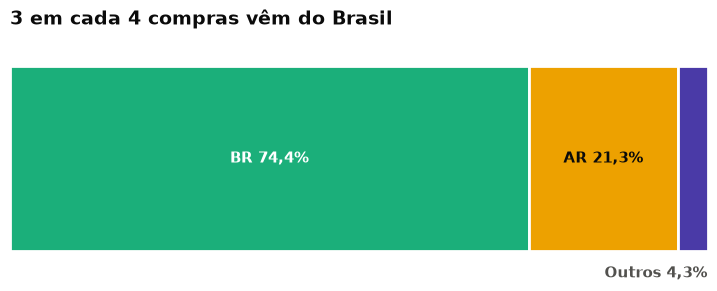

In [45]:
fig, ax = plt.subplots(figsize=(LARGURA / DPI, 2.4))
ax.grid(False)

sns.histplot(
    data=participacao.assign(barra=""), y="barra", weights="compras",
    hue="pais", hue_order=ORDEM_PAIS[::-1], palette=CORES_PAIS,
    multiple="fill", shrink=0.8, alpha=1, edgecolor="white", linewidth=2,
    legend=False, ax=ax,
)

inicio = 0
for pais, pct in zip(participacao["pais"], participacao["percentual"]):
    fim = inicio + pct / 100
    rotulo = f"{pais} {formatar_numero(pct, 1)}%"
    if pct > 10:   # cabe dentro do pedaço
        cor_texto = TINTA_PRINCIPAL if pais == "AR" else "white"
        ax.text((inicio + fim) / 2, 0, rotulo, ha="center", va="center", fontweight="bold", color=cor_texto)
    else:          # pedaço estreito: rótulo abaixo, alinhado à borda direita do pedaço
        ax.text(fim, -0.08, rotulo, ha="right", va="top", fontweight="bold", color=TINTA_SECUNDARIA,
                transform=ax.get_xaxis_transform())
    inicio = fim

ax.set(title=TITULO_PIZZA, xlabel="", ylabel="", xticks=[], yticks=[])
ax.spines[:].set_visible(False)

plt.show()

### plotly

| Personalização | Código | Efeito |
|---|---|---|
| Rosca | `hole=0.58` | Tamanho do buraco (0 = pizza cheia) |
| Ordem fixa | `sort=False` | Sem isso, o plotly reordena as fatias por tamanho |
| Sentido horário | `direction="clockwise"` | Começa às 12h por padrão |
| Rótulos | `textinfo="label+percent"`, `textposition="outside"` | Nome + % fora da rosca |
| Respiro | `marker_line_color="white", marker_line_width=2` | |
| Total no centro | `fig.add_annotation(x=0.5, y=0.5, ...)` | Centro do gráfico |
| Destacar uma fatia | `pull=[0, 0.1, 0]` | (opcional) "puxa" a fatia para fora |

In [46]:
fig = px.pie(
    participacao, names="pais", values="compras", color="pais",
    color_discrete_map=CORES_PAIS,
    hole=0.58, title=TITULO_PIZZA,
)

fig.update_traces(
    sort=False, direction="clockwise",
    textinfo="label+percent", textposition="outside", texttemplate="<b>%{label}</b><br>%{percent:.1%}",
    marker_line_color="white", marker_line_width=2,
    hovertemplate="%{label}: %{value:,.0f} compras (%{percent:.1%})<extra></extra>",
)
fig.add_annotation(text=f"<b>{formatar_numero(TOTAL_COMPRAS)}</b><br>compras", x=0.5, y=0.5,
                   showarrow=False, font=dict(size=16, color=TINTA_PRINCIPAL))
fig.update_layout(showlegend=False)

fig.show()

### Comparando as três

| | matplotlib | seaborn | plotly |
|---|---|---|---|
| Pizza / rosca | `ax.pie` + `wedgeprops` | **Não existe** | `px.pie` + `hole` |
| Ordem das fatias | A dos dados | | Reordena por tamanho, a menos que `sort=False` |
| Total no centro | `ax.text(0, 0, ...)` | | `add_annotation` |
| Interatividade | Não | | Hover + clique na legenda remove a fatia e recalcula as % |

**Escolha para pizza:** plotly para painéis, matplotlib para relatórios. E sempre se pergunte se uma barra não seria mais clara.

**Leitura do exemplo:** o Brasil responde por 74,4% das compras, a Argentina por 21,3% e os demais países somam 4,3%. Como só 3 fatias têm tamanhos bem diferentes, a pizza funciona.

---
## Cola rápida: o mesmo ajuste nas três bibliotecas

| O que você quer | matplotlib | seaborn | plotly express |
|---|---|---|---|
| Cor por grupo | `for grupo, cor in CORES.items()` | `hue="col", palette=CORES` | `color="col", color_discrete_map=CORES` |
| Ordem dos grupos | ordem do loop | `hue_order=[...]`, `order=[...]` | `category_orders={"col": [...]}` |
| Título | `ax.set_title("...")` | `ax.set_title("...")` | `title="..."` |
| Nome dos eixos | `ax.set(xlabel=..., ylabel=...)` | `ax.set(xlabel=..., ylabel=...)` | `labels={"col": "Nome"}` |
| Escala log | `ax.set_xscale("log")` | `ax.set_xscale("log")` ou `log_scale=True` | `log_x=True` |
| Limites do eixo | `ax.set_ylim(0, 100)` | `ax.set_ylim(0, 100)` | `fig.update_yaxes(range=[0, 100])` |
| Eixo em % | `mticker.PercentFormatter()` | `mticker.PercentFormatter()` | `ticksuffix="%"` ou `tickformat=".0%"` |
| Transparência | `alpha=0.5` | `alpha=0.5` | `opacity=0.5` |
| Linha de referência | `ax.axhline(y)` | `ax.axhline(y)` | `fig.add_hline(y=...)` |
| Texto no gráfico | `ax.annotate(...)` | `ax.annotate(...)` | `fig.add_annotation(...)` |
| Legenda no topo | `ax.legend(loc="upper left", bbox_to_anchor=(0, 1.02), ncols=2)` | `sns.move_legend(ax, ...)` | `legend=dict(orientation="h", y=1.02, yanchor="bottom")` |
| Tamanho | `plt.subplots(figsize=(9, 5))` | `plt.subplots(figsize=(9, 5))` | `width=900, height=500` |
| Mostrar | `plt.show()` | `plt.show()` | `fig.show()` |
| Salvar imagem | `fig.savefig("g.png", dpi=150, bbox_inches="tight")` | igual ao matplotlib | `fig.write_image("g.png")` (requer `kaleido`) |
| Salvar interativo | | | `fig.write_html("g.html")` |

## Resumo: qual biblioteca venceu em cada gráfico

| Gráfico | Melhor para explorar | Melhor para apresentar | Por quê |
|---|---|---|---|
| Barras | seaborn | plotly | seaborn agrega e mostra a incerteza; plotly tem hover e legenda clicável |
| Linha | matplotlib / pandas | plotly | Linhas são simples em qualquer lib; o hover unificado do plotly ajuda em séries longas |
| Dispersão | seaborn | plotly | `pairplot`/`regplot` para explorar; hover para identificar pontos |
| Heatmap | seaborn | seaborn | `sns.heatmap` resolve tudo numa chamada |
| Boxplot | seaborn | seaborn / plotly | `hue` automático; plotly mostra os quartis exatos no hover |
| Violino | seaborn | seaborn | `split=True` + `inner="quart"` |
| Histograma | seaborn | seaborn / plotly | `common_norm=False` + `kde=True` |
| Pizza | — | plotly / matplotlib | seaborn não tem |

**Regra de bolso:** seaborn para explorar, matplotlib para ajustar e publicar, plotly para interagir. E o matplotlib está sempre por baixo do seaborn: tudo o que você aprende de `ax.*` serve para os dois.

> **Plotly não aparece?** Se o notebook for aberto no GitHub ou num visualizador estático, os gráficos plotly não são exibidos (eles precisam de JavaScript). Rode o notebook no Jupyter, VS Code ou Colab. Se ainda assim não aparecer, teste `pio.renderers.default = "notebook"` (ou `"vscode"`, `"colab"`).